# Singapore Condo Rent Forecasting — LightGBM v3.3

**Dataset**: `URA_renting_imputed_saits_no_cutoff_macro.csv` — SAITS imputed panel (month × condo-size)

**Three Tasks**:
- **Task A — h=1** : Predict `rent_psf_imp` 1 month ahead
- **Task B — h=12**: Predict `rent_psf_imp` 12 months ahead (GAP=11)
- **Task C — h=24**: Predict `rent_psf_imp` 24 months ahead (GAP=23) ← NEW

**Method**: LightGBM + Optuna Bayesian Hyperparameter Search + Early Stopping + Walk-Forward CV

**Test cutoff**: `TEST_CUTOFF = 202001`

**Changes in v3.3 vs v3.2**:
- ✅ Removed `is_post_cutoff` from features (constant False — zero variance)
- ✅ Replaced `GridSearchCV` with **Optuna** Bayesian optimization (100 trials per task)
- ✅ Added **early stopping** (n_estimators=3000, patience=50) to prevent overfitting
- ✅ Added **Task C — h=24** with lag-24 features and GAP=23
- ✅ Expanded hyperparameter search space (num_leaves, min_child_samples, subsample, colsample_bytree, reg_lambda, reg_alpha)

## 1. Imports

In [ ]:
import warnings, re, random, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# import lightgbm as lgb
# from lightgbm import LGBMRegressor

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print('Optuna available ✅')
except ImportError:
    OPTUNA_AVAILABLE = False
    print('pip install optuna')

try:
    import shap; SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('pip install shap for SHAP plots')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
random.seed(42)
np.random.seed(42)
# print(f'LightGBM {lgb.__version__}  pandas {pd.__version__}  — ready.')

Optuna available ✅
LightGBM 4.6.0  pandas 3.0.2  — ready.


## 2. Load SAITS-Imputed Panel

In [ ]:
CSV_PATH = r'dataset/URA_renting_imputed_saits_no_cutoff_macro.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df = df.sort_values(['project_idx', 'date']).reset_index(drop=True)

df['period']        = df['date'].dt.year * 100 + df['date'].dt.month
df['month_of_year'] = df['date'].dt.month
df['lease_year']    = df['date'].dt.year

print(f'Loaded: {len(df):,} rows x {len(df.columns)} columns')
print(f'Projects   : {df["project_idx"].nunique():,}')
print(f'Date range : {df["date"].min().strftime("%Y-%m")} → {df["date"].max().strftime("%Y-%m")}')
print(f'Period     : {df["period"].min()} → {df["period"].max()}')
print(f'was_observed distribution:')
print(df['was_observed'].value_counts(normalize=True).rename({True: 'Observed', False: 'Imputed'}))

Loaded: 711,585 rows x 174 columns
Projects   : 2,259
Date range : 1999-11 → 2026-01
Period     : 199911 → 202601
was_observed distribution:
was_observed
Imputed    0.7697
Observed   0.2303
Name: proportion, dtype: float64


## 3. Fix Missing condo_name + Fill Missing Values

In [3]:
def convert_range_to_number(s):
    if pd.isna(s) or not isinstance(s, str): return np.nan
    parts = s.replace(',', '').split(' to ')
    try: return sum([float(p) for p in parts]) / len(parts)
    except: return np.nan

def make_size_bucket(area_sqft, q=5):
    s_valid = area_sqft.dropna()
    out = pd.Series(index=area_sqft.index, dtype='object')
    if s_valid.nunique() < 2: out[:] = 'SZ1'; return out
    q_use = min(q, int(s_valid.nunique()))
    lab_use = [f'SZ{i+1}' for i in range(q_use)]
    try: bkt = pd.qcut(s_valid.rank(method='first'), q=q_use, labels=lab_use, duplicates='drop')
    except: bkt = pd.cut(s_valid, bins=q_use, labels=lab_use, include_lowest=True, duplicates='drop')
    out.loc[s_valid.index] = bkt.astype(str)
    return out.fillna('SZ1')

if (df['condo_name'].isna() | (df['condo_name'] == 'Unknown')).any():
    df_tmp = pd.read_csv('URA_merged_full_v3.csv',
                         usecols=['Project Name', 'Postal District', 'Floor Area (SQFT)'])
    df_tmp = df_tmp[pd.to_numeric(df_tmp['Postal District'], errors='coerce').isin([1,2,9,10,11])]
    df_tmp['Area'] = df_tmp['Floor Area (SQFT)'].apply(convert_range_to_number)
    df_tmp['sz']   = make_size_bucket(df_tmp['Area'], q=5)
    df_tmp['ps']   = df_tmp['Project Name'].astype(str).str.strip() + ' | ' + df_tmp['sz']
    idx_to_series  = {i: name for i, name in enumerate(sorted(df_tmp['ps'].unique()))}
    slm = {'SZ1':'very_small','SZ2':'small','SZ3':'medium','SZ4':'large','SZ5':'very_large'}
    mask = df['condo_name'].isna() | (df['condo_name'] == 'Unknown')
    df.loc[mask, 'condo_name'] = df.loc[mask, 'project_idx']\
        .map(lambda i: idx_to_series.get(i, 'Unknown | Unknown').rsplit(' | ', 1)[0])
    df.loc[mask, 'size_tier']  = df.loc[mask, 'project_idx']\
        .map(lambda i: idx_to_series.get(i, 'Unknown | Unknown').rsplit(' | ', 1)[-1])
    df.loc[mask, 'size_label'] = df['size_tier'].map(slm)
    print(f'Fixed condo_name. Still missing: {df["condo_name"].isna().sum()}')
else:
    print('condo_name OK ✅')

condo_name OK ✅


In [4]:
amenity_dist_cols = [c for c in df.columns if c.startswith('nearest_')
                     and c not in ['nearest_mrt_dist', 'nearest_mrt_name',
                                   'nearest_school_dist', 'nearest_school_name']]
for col in amenity_dist_cols:
    df[col] = df[col].fillna(df[col].median())

for col in [c for c in df.columns if c.endswith('_top3')]:
    df[col] = df[col].fillna(0)

school_dist_cols = [c for c in df.columns
                    if 'School' in c or 'Junior' in c or 'Institution' in c]
for col in school_dist_cols + ['nearest_school_dist']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if 'nearest_school_name' in df.columns:
    df['nearest_school_name'] = df['nearest_school_name'].fillna('Unknown')

for col in ['latitude', 'longitude']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df['Condo_Age_2026'] = df.groupby('district')['Condo_Age_2026']\
    .transform(lambda x: x.fillna(x.median()))
df['Condo_Age_2026'] = df['Condo_Age_2026'].fillna(df['Condo_Age_2026'].median())
df['tenure_remaining_years'] = df['tenure_remaining_years']\
    .fillna(df['tenure_remaining_years'].median())

macro_cols = [
    'cpi_all_items_infl_yoy_pct', 'unemployment_rate_sa_pct',
    'sora_compounded_3m_pct', 'sg_govt_bond_yield_10y_pct',
    'sgd_per_usd_logret_12m_pct', 'ura_private_rental_index_yoy_pct',
    'ura_private_price_index_avg_3seg_yoy_pct',
    'hdb_resale_price_index_yoy_pct', 'gva_yoy_growth_pct',
    'rental_index_nonlanded_yoy_log_growth_lag1q',
    'rental_index_nonlanded_in_ccr_yoy_log_growth_lag1q',
    'rental_index_nonlanded_in_ocr_yoy_log_growth_lag1q',
    'rental_index_nonlanded_in_rcr_yoy_log_growth_lag1q',
    'ppi_nonlanded_yoy_log_growth_lag1q',
    'ppi_nonlanded_in_ccr_yoy_log_growth_lag1q',
    'ppi_nonlanded_in_ocr_yoy_log_growth_lag1q',
    'ppi_nonlanded_in_rcr_yoy_log_growth_lag1q',
    'log1p_vacant_nonlanded_units_lag1q',
    'vacancy_rate_nonlanded_units_lag1q',
    'log1p_nonlanded_private_units_in_the_pipeline_lag1q',
    'nonlanded_private_units_in_the_pipeline_under_construction_share_lag1q',
    'log1p_non_landed_units_launched_in_private_res_projects_with_prereq_for_sale_lag1q',
    'non_landed_units_in_private_res_projects_with_prereq_not_launched_share_lag1q',
    'log1p_unsold_completed_nonlanded_private_units_lag1q',
    'log1p_unsold_non_landed_units_in_launched_private_res_projects_lag1q',
    'assessed_non_landed_private_residential_owned_by_companies_share_lag1q',
    'assessed_non_landed_private_residential_owned_by_pr_foreigners_share_lag1q',
    'uncompleted_non_landed_private_residential_purchased_by_companies_share_lag1q',
    'uncompleted_non_landed_private_residential_purchased_by_foreigners_share_lag1q',
    'uncompleted_non_landed_private_residential_purchased_by_spr_share_lag1q',
]
macro_cols = [c for c in macro_cols if c in df.columns]
df[macro_cols] = df.sort_values('date').groupby('date')[macro_cols].transform('first')
df[macro_cols] = df[macro_cols].ffill().bfill()

df['Large_Dev_200plus'] = df['Large_Dev_200plus'].fillna(0)
for col in ['project_size_small', 'project_size_medium', 'project_size_large']:
    if col in df.columns: df[col] = df[col].fillna(0)
df['nearest_mrt_dist'] = df['nearest_mrt_dist'].fillna(df['nearest_mrt_dist'].median())
for col in ['Planning Area', 'Neighbourhood', 'condo_name', 'size_tier',
            'size_label', 'segment', 'nearest_mrt_name']:
    if col in df.columns: df[col] = df[col].fillna('Unknown')
for col in df.select_dtypes(include='number').columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

miss = df.isna().sum()
print('Missing after fill:', miss[miss > 0].to_dict() if miss.sum() > 0 else 'None ✅')

Missing after fill: {'nearest_bus_stops_dist': 711585, 'nearest_supermarkets_dist': 711585, 'nearest_parks_dist': 711585, 'nearest_clinics_dist': 711585, 'nearest_bank_dist': 711585, 'nearest_atms_dist': 711585, 'Rosyth School': 711585, "St. Hilda's Primary School": 711585, "Chij St. Nicholas Girls' School": 711585, 'Rulanh Primary School': 711585, 'Ai Tong School': 711585, 'South View Primary School': 711585, 'Chongfu School': 711585, "Holy Innocents' Primary School": 711585, 'Maris Stella High School (Primary)': 711585, 'Canberra Primary School': 711585, 'Gongshang Primary School': 711585, 'Anderson Primary School': 711585, 'Princess Elizabeth Primary School': 711585}


## 4. Feature Engineering

In [5]:
month_grid = pd.DataFrame({
    'date': pd.date_range(df['date'].min(), df['date'].max(), freq='MS')
})
month_grid['period'] = month_grid['date'].dt.year * 100 + month_grid['date'].dt.month

# Global lags (lag-1)
glob_obs = df.groupby('period')['rent_psf_imp'].median().reset_index()\
             .rename(columns={'rent_psf_imp': '_raw'})
glob = month_grid.merge(glob_obs, on='period', how='left')\
                 .sort_values('period').reset_index(drop=True)
glob['glob_med_1m']  = glob['_raw'].shift(1)
glob['glob_med_3m']  = glob['_raw'].shift(1).rolling(3,  min_periods=1).mean()
glob['glob_med_12m'] = glob['_raw'].shift(1).rolling(12, min_periods=3).mean()
glob['glob_trend']   = glob['glob_med_1m'] - glob['glob_med_12m']
df = df.merge(
    glob[['period', 'glob_med_1m', 'glob_med_3m', 'glob_med_12m', 'glob_trend']],
    on='period', how='left'
)

# District lags (lag-1)
dist_obs = df.groupby(['district', 'period'])['rent_psf_imp'].median().reset_index()\
             .rename(columns={'rent_psf_imp': '_raw'})
dist_parts = []
for d in df['district'].dropna().unique():
    g = month_grid[['period']].copy(); g['district'] = d
    g = g.merge(dist_obs[dist_obs['district']==d][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['dist_med_1m']  = g['_raw'].shift(1)
    g['dist_med_3m']  = g['_raw'].shift(1).rolling(3,  min_periods=1).mean()
    g['dist_med_12m'] = g['_raw'].shift(1).rolling(12, min_periods=3).mean()
    g['dist_trend']   = g['dist_med_1m'] - g['dist_med_12m']
    dist_parts.append(g)
dist_lag = pd.concat(dist_parts, ignore_index=True)
df = df.merge(
    dist_lag[['district','period','dist_med_1m','dist_med_3m','dist_med_12m','dist_trend']],
    on=['district','period'], how='left'
)

# Condo lags (lag-1) with fallback
condo_obs = df.groupby(['project_idx','period'])['rent_psf_imp'].median().reset_index()\
              .rename(columns={'rent_psf_imp': '_raw'})
condo_parts = []
for pid in df['project_idx'].unique():
    g = month_grid[['period']].copy(); g['project_idx'] = pid
    g = g.merge(condo_obs[condo_obs['project_idx']==pid][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['condo_level_1m']  = g['_raw'].shift(1)
    g['condo_level_12m'] = g['_raw'].shift(1).rolling(12, min_periods=3).mean()
    condo_parts.append(g)
condo_lag = pd.concat(condo_parts, ignore_index=True)
df = df.merge(
    condo_lag[['project_idx','period','condo_level_1m','condo_level_12m']],
    on=['project_idx','period'], how='left'
)
df['condo_level_1m']  = df['condo_level_1m'].fillna(df['dist_med_1m']).fillna(df['glob_med_1m'])
df['condo_level_12m'] = df['condo_level_12m'].fillna(df['dist_med_12m']).fillna(df['glob_med_12m'])

print('Lag-1 features built.')

Lag-1 features built.


In [6]:
# ── Lag-12 features for Task B (h=12) ────────────────────────────────────────
glob_t12 = month_grid.merge(glob_obs, on='period', how='left') \
                     .sort_values('period').reset_index(drop=True)
glob_t12['glob_med_1m_t12']  = glob_t12['_raw'].shift(12)
glob_t12['glob_med_3m_t12']  = glob_t12['_raw'].shift(12).rolling(3,  min_periods=1).mean()
glob_t12['glob_med_12m_t12'] = glob_t12['_raw'].shift(12).rolling(12, min_periods=3).mean()
glob_t12['glob_trend_t12']   = glob_t12['glob_med_1m_t12'] - glob_t12['glob_med_12m_t12']
df = df.merge(
    glob_t12[['period', 'glob_med_1m_t12', 'glob_med_3m_t12', 'glob_med_12m_t12', 'glob_trend_t12']],
    on='period', how='left'
)

dist_parts_t12 = []
for d in df['district'].dropna().unique():
    g = month_grid[['period']].copy(); g['district'] = d
    g = g.merge(dist_obs[dist_obs['district']==d][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['dist_med_1m_t12']  = g['_raw'].shift(12)
    g['dist_med_3m_t12']  = g['_raw'].shift(12).rolling(3,  min_periods=1).mean()
    g['dist_med_12m_t12'] = g['_raw'].shift(12).rolling(12, min_periods=3).mean()
    g['dist_trend_t12']   = g['dist_med_1m_t12'] - g['dist_med_12m_t12']
    dist_parts_t12.append(g)
dist_lag_t12 = pd.concat(dist_parts_t12, ignore_index=True)
df = df.merge(
    dist_lag_t12[['district', 'period', 'dist_med_1m_t12', 'dist_med_3m_t12',
                  'dist_med_12m_t12', 'dist_trend_t12']],
    on=['district', 'period'], how='left'
)

condo_parts_t12 = []
for pid in df['project_idx'].unique():
    g = month_grid[['period']].copy(); g['project_idx'] = pid
    g = g.merge(condo_obs[condo_obs['project_idx']==pid][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['condo_level_1m_t12']  = g['_raw'].shift(12)
    g['condo_level_12m_t12'] = g['_raw'].shift(12).rolling(12, min_periods=3).mean()
    condo_parts_t12.append(g)
condo_lag_t12 = pd.concat(condo_parts_t12, ignore_index=True)
df = df.merge(
    condo_lag_t12[['project_idx', 'period', 'condo_level_1m_t12', 'condo_level_12m_t12']],
    on=['project_idx', 'period'], how='left'
)
df['condo_level_1m_t12']  = df['condo_level_1m_t12'].fillna(df['dist_med_1m_t12']).fillna(df['glob_med_1m_t12'])
df['condo_level_12m_t12'] = df['condo_level_12m_t12'].fillna(df['dist_med_12m_t12']).fillna(df['glob_med_12m_t12'])

print('Lag-12 features built.')

Lag-12 features built.


In [7]:
# ── Lag-24 features for Task C (h=24) ── NEW in v3.3 ─────────────────────────
glob_t24 = month_grid.merge(glob_obs, on='period', how='left') \
                     .sort_values('period').reset_index(drop=True)
glob_t24['glob_med_1m_t24']  = glob_t24['_raw'].shift(24)
glob_t24['glob_med_3m_t24']  = glob_t24['_raw'].shift(24).rolling(3,  min_periods=1).mean()
glob_t24['glob_med_12m_t24'] = glob_t24['_raw'].shift(24).rolling(12, min_periods=3).mean()
glob_t24['glob_trend_t24']   = glob_t24['glob_med_1m_t24'] - glob_t24['glob_med_12m_t24']
df = df.merge(
    glob_t24[['period', 'glob_med_1m_t24', 'glob_med_3m_t24', 'glob_med_12m_t24', 'glob_trend_t24']],
    on='period', how='left'
)

dist_parts_t24 = []
for d in df['district'].dropna().unique():
    g = month_grid[['period']].copy(); g['district'] = d
    g = g.merge(dist_obs[dist_obs['district']==d][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['dist_med_1m_t24']  = g['_raw'].shift(24)
    g['dist_med_3m_t24']  = g['_raw'].shift(24).rolling(3,  min_periods=1).mean()
    g['dist_med_12m_t24'] = g['_raw'].shift(24).rolling(12, min_periods=3).mean()
    g['dist_trend_t24']   = g['dist_med_1m_t24'] - g['dist_med_12m_t24']
    dist_parts_t24.append(g)
dist_lag_t24 = pd.concat(dist_parts_t24, ignore_index=True)
df = df.merge(
    dist_lag_t24[['district', 'period', 'dist_med_1m_t24', 'dist_med_3m_t24',
                  'dist_med_12m_t24', 'dist_trend_t24']],
    on=['district', 'period'], how='left'
)

condo_parts_t24 = []
for pid in df['project_idx'].unique():
    g = month_grid[['period']].copy(); g['project_idx'] = pid
    g = g.merge(condo_obs[condo_obs['project_idx']==pid][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['condo_level_1m_t24']  = g['_raw'].shift(24)
    g['condo_level_12m_t24'] = g['_raw'].shift(24).rolling(12, min_periods=3).mean()
    condo_parts_t24.append(g)
condo_lag_t24 = pd.concat(condo_parts_t24, ignore_index=True)
df = df.merge(
    condo_lag_t24[['project_idx', 'period', 'condo_level_1m_t24', 'condo_level_12m_t24']],
    on=['project_idx', 'period'], how='left'
)
df['condo_level_1m_t24']  = df['condo_level_1m_t24'].fillna(df['dist_med_1m_t24']).fillna(df['glob_med_1m_t24'])
df['condo_level_12m_t24'] = df['condo_level_12m_t24'].fillna(df['dist_med_12m_t24']).fillna(df['glob_med_12m_t24'])

print('Lag-24 features built.')

Lag-24 features built.


In [8]:
# ── Obs-only lag features for no-imp baseline ─────────────────────────────────
df['_obs_raw'] = df['rent_psf_obs']

glob_obs2 = df.groupby('period')['_obs_raw'].median().reset_index().rename(columns={'_obs_raw': '_raw'})
glob2 = month_grid.merge(glob_obs2, on='period', how='left').sort_values('period').reset_index(drop=True)
glob2['glob_med_1m_obs']  = glob2['_raw'].shift(1)
glob2['glob_med_3m_obs']  = glob2['_raw'].shift(1).rolling(3,  min_periods=1).mean()
glob2['glob_med_12m_obs'] = glob2['_raw'].shift(1).rolling(12, min_periods=3).mean()
glob2['glob_trend_obs']   = glob2['glob_med_1m_obs'] - glob2['glob_med_12m_obs']
df = df.merge(glob2[['period','glob_med_1m_obs','glob_med_3m_obs','glob_med_12m_obs','glob_trend_obs']], on='period', how='left')

dist_obs2 = df.groupby(['district','period'])['_obs_raw'].median().reset_index().rename(columns={'_obs_raw': '_raw'})
dist_parts2 = []
for d in df['district'].dropna().unique():
    g = month_grid[['period']].copy(); g['district'] = d
    g = g.merge(dist_obs2[dist_obs2['district']==d][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['dist_med_1m_obs']  = g['_raw'].shift(1)
    g['dist_med_3m_obs']  = g['_raw'].shift(1).rolling(3,  min_periods=1).mean()
    g['dist_med_12m_obs'] = g['_raw'].shift(1).rolling(12, min_periods=3).mean()
    g['dist_trend_obs']   = g['dist_med_1m_obs'] - g['dist_med_12m_obs']
    dist_parts2.append(g)
dist_lag2 = pd.concat(dist_parts2, ignore_index=True)
df = df.merge(dist_lag2[['district','period','dist_med_1m_obs','dist_med_3m_obs','dist_med_12m_obs','dist_trend_obs']], on=['district','period'], how='left')

condo_obs2 = df.groupby(['project_idx','period'])['_obs_raw'].median().reset_index().rename(columns={'_obs_raw': '_raw'})
condo_parts2 = []
for pid in df['project_idx'].unique():
    g = month_grid[['period']].copy(); g['project_idx'] = pid
    g = g.merge(condo_obs2[condo_obs2['project_idx']==pid][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['condo_level_1m_obs']  = g['_raw'].shift(1)
    g['condo_level_12m_obs'] = g['_raw'].shift(1).rolling(12, min_periods=3).mean()
    condo_parts2.append(g)
condo_lag2 = pd.concat(condo_parts2, ignore_index=True)
df = df.merge(condo_lag2[['project_idx','period','condo_level_1m_obs','condo_level_12m_obs']], on=['project_idx','period'], how='left')
df['condo_level_1m_obs']  = df['condo_level_1m_obs'].fillna(df['dist_med_1m_obs']).fillna(df['glob_med_1m_obs'])
df['condo_level_12m_obs'] = df['condo_level_12m_obs'].fillna(df['dist_med_12m_obs']).fillna(df['glob_med_12m_obs'])

# Lag-12 obs versions
glob2_t12 = month_grid.merge(glob_obs2, on='period', how='left').sort_values('period').reset_index(drop=True)
glob2_t12['glob_med_1m_obs_t12']  = glob2_t12['_raw'].shift(12)
glob2_t12['glob_med_3m_obs_t12']  = glob2_t12['_raw'].shift(12).rolling(3,  min_periods=1).mean()
glob2_t12['glob_med_12m_obs_t12'] = glob2_t12['_raw'].shift(12).rolling(12, min_periods=3).mean()
glob2_t12['glob_trend_obs_t12']   = glob2_t12['glob_med_1m_obs_t12'] - glob2_t12['glob_med_12m_obs_t12']
df = df.merge(glob2_t12[['period','glob_med_1m_obs_t12','glob_med_3m_obs_t12','glob_med_12m_obs_t12','glob_trend_obs_t12']], on='period', how='left')

dist_parts2_t12 = []
for d in df['district'].dropna().unique():
    g = month_grid[['period']].copy(); g['district'] = d
    g = g.merge(dist_obs2[dist_obs2['district']==d][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['dist_med_1m_obs_t12']  = g['_raw'].shift(12)
    g['dist_med_3m_obs_t12']  = g['_raw'].shift(12).rolling(3,  min_periods=1).mean()
    g['dist_med_12m_obs_t12'] = g['_raw'].shift(12).rolling(12, min_periods=3).mean()
    g['dist_trend_obs_t12']   = g['dist_med_1m_obs_t12'] - g['dist_med_12m_obs_t12']
    dist_parts2_t12.append(g)
dist_lag2_t12 = pd.concat(dist_parts2_t12, ignore_index=True)
df = df.merge(dist_lag2_t12[['district','period','dist_med_1m_obs_t12','dist_med_3m_obs_t12','dist_med_12m_obs_t12','dist_trend_obs_t12']], on=['district','period'], how='left')

condo_parts2_t12 = []
for pid in df['project_idx'].unique():
    g = month_grid[['period']].copy(); g['project_idx'] = pid
    g = g.merge(condo_obs2[condo_obs2['project_idx']==pid][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['condo_level_1m_obs_t12']  = g['_raw'].shift(12)
    g['condo_level_12m_obs_t12'] = g['_raw'].shift(12).rolling(12, min_periods=3).mean()
    condo_parts2_t12.append(g)
condo_lag2_t12 = pd.concat(condo_parts2_t12, ignore_index=True)
df = df.merge(condo_lag2_t12[['project_idx','period','condo_level_1m_obs_t12','condo_level_12m_obs_t12']], on=['project_idx','period'], how='left')
df['condo_level_1m_obs_t12']  = df['condo_level_1m_obs_t12'].fillna(df['dist_med_1m_obs_t12']).fillna(df['glob_med_1m_obs_t12'])
df['condo_level_12m_obs_t12'] = df['condo_level_12m_obs_t12'].fillna(df['dist_med_12m_obs_t12']).fillna(df['glob_med_12m_obs_t12'])


# ── Lag-24 obs features for no-imp baseline ──────────────────────────────────
glob2_t24 = month_grid.merge(glob_obs2, on='period', how='left').sort_values('period').reset_index(drop=True)
glob2_t24['glob_med_1m_obs_t24']  = glob2_t24['_raw'].shift(24)
glob2_t24['glob_med_3m_obs_t24']  = glob2_t24['_raw'].shift(24).rolling(3,  min_periods=1).mean()
glob2_t24['glob_med_12m_obs_t24'] = glob2_t24['_raw'].shift(24).rolling(12, min_periods=3).mean()
glob2_t24['glob_trend_obs_t24']   = glob2_t24['glob_med_1m_obs_t24'] - glob2_t24['glob_med_12m_obs_t24']
df = df.merge(glob2_t24[['period','glob_med_1m_obs_t24','glob_med_3m_obs_t24','glob_med_12m_obs_t24','glob_trend_obs_t24']], on='period', how='left')

dist_parts2_t24 = []
for d in df['district'].dropna().unique():
    g = month_grid[['period']].copy(); g['district'] = d
    g = g.merge(dist_obs2[dist_obs2['district']==d][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['dist_med_1m_obs_t24']  = g['_raw'].shift(24)
    g['dist_med_3m_obs_t24']  = g['_raw'].shift(24).rolling(3,  min_periods=1).mean()
    g['dist_med_12m_obs_t24'] = g['_raw'].shift(24).rolling(12, min_periods=3).mean()
    g['dist_trend_obs_t24']   = g['dist_med_1m_obs_t24'] - g['dist_med_12m_obs_t24']
    dist_parts2_t24.append(g)
dist_lag2_t24 = pd.concat(dist_parts2_t24, ignore_index=True)
df = df.merge(dist_lag2_t24[['district','period','dist_med_1m_obs_t24','dist_med_3m_obs_t24','dist_med_12m_obs_t24','dist_trend_obs_t24']], on=['district','period'], how='left')

condo_parts2_t24 = []
for pid in df['project_idx'].unique():
    g = month_grid[['period']].copy(); g['project_idx'] = pid
    g = g.merge(condo_obs2[condo_obs2['project_idx']==pid][['period','_raw']], on='period', how='left')
    g = g.sort_values('period')
    g['condo_level_1m_obs_t24']  = g['_raw'].shift(24)
    g['condo_level_12m_obs_t24'] = g['_raw'].shift(24).rolling(12, min_periods=3).mean()
    condo_parts2_t24.append(g)
condo_lag2_t24 = pd.concat(condo_parts2_t24, ignore_index=True)
df = df.merge(condo_lag2_t24[['project_idx','period','condo_level_1m_obs_t24','condo_level_12m_obs_t24']], on=['project_idx','period'], how='left')
df['condo_level_1m_obs_t24']  = df['condo_level_1m_obs_t24'].fillna(df['dist_med_1m_obs_t24']).fillna(df['glob_med_1m_obs_t24'])
df['condo_level_12m_obs_t24'] = df['condo_level_12m_obs_t24'].fillna(df['dist_med_12m_obs_t24']).fillna(df['glob_med_12m_obs_t24'])

print('Lag-24 obs features built.')

df.drop(columns=['_obs_raw'], inplace=True)
print('Obs-only lag features built.')

Lag-24 obs features built.
Obs-only lag features built.


In [9]:
# Observation density features
df['obs_frac_12m'] = df.groupby('project_idx')['was_observed']\
    .transform(lambda x: x.shift(1).rolling(12, min_periods=1).mean())
df['obs_frac_12m_t12'] = df.groupby('project_idx')['was_observed']\
    .transform(lambda x: x.shift(12).rolling(12, min_periods=1).mean())
df['obs_frac_12m_t24'] = df.groupby('project_idx')['was_observed']\
    .transform(lambda x: x.shift(24).rolling(12, min_periods=1).mean())

df['Postal District'] = df['district'].astype(str)
CAT_FEATURES = ['Postal District', 'Planning Area', 'Neighbourhood', 'size_tier']
CAT_FEATURES = [c for c in CAT_FEATURES if c in df.columns]
for col in CAT_FEATURES:
    df[col] = df[col].astype('category')

print(f'Categorical features: {CAT_FEATURES}')

Categorical features: ['Postal District', 'Planning Area', 'Neighbourhood', 'size_tier']


In [10]:
# ── Feature lists ─────────────────────────────────────────────────────────────
# NOTE v3.3: is_post_cutoff REMOVED (constant False — zero variance, no signal)
BASE_FEATURES = [
    'area_sqft_med', 'Condo_Age_2026',
    'tenure_freehold_like', 'tenure_medium_lease_60_80',
    'tenure_more_than_80', 'tenure_short_lease_lt60',
    'tenure_unknown', 'tenure_remaining_years',
    'project_size_small', 'project_size_medium', 'project_size_large',
    'Large_Dev_200plus',
    'Postal District', 'Planning Area', 'Neighbourhood',
    'nearest_mrt_dist', 'size_tier',
    'nearest_bus_stops_dist', 'n_bus_stops_top3',
    'nearest_supermarkets_dist', 'n_supermarkets_top3',
    'nearest_parks_dist', 'n_parks_top3',
    'nearest_clinics_dist', 'n_clinics_top3',
    'nearest_bank_dist', 'n_bank_top3',
    'nearest_atms_dist', 'n_atms_top3',
    'nearest_school_dist',
    'latitude', 'longitude',
    # is_post_cutoff REMOVED in v3.3
    'month_of_year',
    'glob_med_1m', 'glob_med_3m', 'glob_med_12m', 'glob_trend',
    'dist_med_1m', 'dist_med_3m', 'dist_med_12m', 'dist_trend',
    'condo_level_1m', 'condo_level_12m',
    'obs_frac_12m',
    'ura_private_rental_index_yoy_pct', 'sora_compounded_3m_pct',
    'gva_yoy_growth_pct', 'cpi_all_items_infl_yoy_pct',
    'unemployment_rate_sa_pct', 'sg_govt_bond_yield_10y_pct',
    'sgd_per_usd_logret_12m_pct', 'ura_private_price_index_avg_3seg_yoy_pct',
    'hdb_resale_price_index_yoy_pct',
    'rental_index_nonlanded_yoy_log_growth_lag1q',
    'rental_index_nonlanded_in_ccr_yoy_log_growth_lag1q',
    'rental_index_nonlanded_in_ocr_yoy_log_growth_lag1q',
    'rental_index_nonlanded_in_rcr_yoy_log_growth_lag1q',
    'ppi_nonlanded_yoy_log_growth_lag1q',
    'ppi_nonlanded_in_ccr_yoy_log_growth_lag1q',
    'ppi_nonlanded_in_ocr_yoy_log_growth_lag1q',
    'ppi_nonlanded_in_rcr_yoy_log_growth_lag1q',
    'log1p_vacant_nonlanded_units_lag1q',
    'vacancy_rate_nonlanded_units_lag1q',
    'log1p_nonlanded_private_units_in_the_pipeline_lag1q',
    'nonlanded_private_units_in_the_pipeline_under_construction_share_lag1q',
    'log1p_non_landed_units_launched_in_private_res_projects_with_prereq_for_sale_lag1q',
    'non_landed_units_in_private_res_projects_with_prereq_not_launched_share_lag1q',
    'log1p_unsold_completed_nonlanded_private_units_lag1q',
    'log1p_unsold_non_landed_units_in_launched_private_res_projects_lag1q',
    'assessed_non_landed_private_residential_owned_by_companies_share_lag1q',
    'assessed_non_landed_private_residential_owned_by_pr_foreigners_share_lag1q',
    'uncompleted_non_landed_private_residential_purchased_by_companies_share_lag1q',
    'uncompleted_non_landed_private_residential_purchased_by_foreigners_share_lag1q',
    'uncompleted_non_landed_private_residential_purchased_by_spr_share_lag1q'
]

HAS_COLS   = sorted([c for c in df.columns if c.startswith('Has_')])
FEATURES_A = list(dict.fromkeys(BASE_FEATURES + HAS_COLS))
FEATURES_A = [c for c in FEATURES_A if c in df.columns]
CAT_FEATURES_A = [c for c in CAT_FEATURES if c in FEATURES_A]

# Observed-only baseline
LAG_IMP_COLS = ['glob_med_1m', 'glob_med_3m', 'glob_med_12m', 'glob_trend',
                 'dist_med_1m', 'dist_med_3m', 'dist_med_12m', 'dist_trend',
                 'condo_level_1m', 'condo_level_12m']
FEATURES_OBS = [
    f for f in FEATURES_A if f not in LAG_IMP_COLS
] + ['glob_med_1m_obs', 'glob_med_3m_obs', 'glob_med_12m_obs', 'glob_trend_obs',
     'dist_med_1m_obs', 'dist_med_3m_obs', 'dist_med_12m_obs', 'dist_trend_obs',
     'condo_level_1m_obs', 'condo_level_12m_obs']
FEATURES_OBS = [f for f in FEATURES_OBS if f in df.columns]
CAT_FEATURES_OBS = CAT_FEATURES_A.copy()

# Task B (h=12): replace lag-1 with lag-12
LAG1_COLS  = ['glob_med_1m', 'glob_med_3m', 'glob_med_12m', 'glob_trend',
              'dist_med_1m', 'dist_med_3m', 'dist_med_12m', 'dist_trend',
              'condo_level_1m', 'condo_level_12m', 'obs_frac_12m']
LAG12_COLS = ['glob_med_1m_t12', 'glob_med_3m_t12', 'glob_med_12m_t12', 'glob_trend_t12',
              'dist_med_1m_t12', 'dist_med_3m_t12', 'dist_med_12m_t12', 'dist_trend_t12',
              'condo_level_1m_t12', 'condo_level_12m_t12', 'obs_frac_12m_t12']
FEATURES_T12_BASE = list(dict.fromkeys(
    [f for f in FEATURES_A if f not in LAG1_COLS] + LAG12_COLS
))
FEATURES_T12_OBS_BASE = list(dict.fromkeys(
    [f for f in FEATURES_OBS if f not in
     ['glob_med_1m_obs', 'glob_med_3m_obs', 'glob_med_12m_obs', 'glob_trend_obs',
      'dist_med_1m_obs', 'dist_med_3m_obs', 'dist_med_12m_obs', 'dist_trend_obs',
      'condo_level_1m_obs', 'condo_level_12m_obs', 'obs_frac_12m']]
    + ['glob_med_1m_obs_t12', 'glob_med_3m_obs_t12', 'glob_med_12m_obs_t12', 'glob_trend_obs_t12',
       'dist_med_1m_obs_t12', 'dist_med_3m_obs_t12', 'dist_med_12m_obs_t12', 'dist_trend_obs_t12',
       'condo_level_1m_obs_t12', 'condo_level_12m_obs_t12', 'obs_frac_12m_t12']
))

# Task C (h=24): replace lag-1 with lag-24 ── NEW v3.3
LAG24_COLS = ['glob_med_1m_t24', 'glob_med_3m_t24', 'glob_med_12m_t24', 'glob_trend_t24',
              'dist_med_1m_t24', 'dist_med_3m_t24', 'dist_med_12m_t24', 'dist_trend_t24',
              'condo_level_1m_t24', 'condo_level_12m_t24', 'obs_frac_12m_t24']
FEATURES_T24_BASE = list(dict.fromkeys(
    [f for f in FEATURES_A if f not in LAG1_COLS] + LAG24_COLS
))


# Task C No-Imputation baseline (h=24) — NEW v3.3+
LAG24_OBS_COLS = ['glob_med_1m_obs_t24', 'glob_med_3m_obs_t24', 'glob_med_12m_obs_t24', 'glob_trend_obs_t24',
                  'dist_med_1m_obs_t24', 'dist_med_3m_obs_t24', 'dist_med_12m_obs_t24', 'dist_trend_obs_t24',
                  'condo_level_1m_obs_t24', 'condo_level_12m_obs_t24', 'obs_frac_12m_t24']
FEATURES_T24_OBS_BASE = list(dict.fromkeys(
    [f for f in FEATURES_OBS if f not in
     ['glob_med_1m_obs', 'glob_med_3m_obs', 'glob_med_12m_obs', 'glob_trend_obs',
      'dist_med_1m_obs', 'dist_med_3m_obs', 'dist_med_12m_obs', 'dist_trend_obs',
      'condo_level_1m_obs', 'condo_level_12m_obs', 'obs_frac_12m']]
    + LAG24_OBS_COLS
))

print(f'Task A features          : {len(FEATURES_A)}  ({len(CAT_FEATURES_A)} categorical)')
print(f'Observed-only features   : {len(FEATURES_OBS)}  ({len(CAT_FEATURES_OBS)} categorical)')
print(f'Task B features (h=12)   : {len(FEATURES_T12_BASE)}')
print(f'Task C features (h=24)   : {len(FEATURES_T24_BASE)}')
print(f'Task C Obs-only (h=24)   : {len(FEATURES_T24_OBS_BASE)}')

Task A features          : 138  (4 categorical)
Observed-only features   : 138  (4 categorical)
Task B features (h=12)   : 138
Task C features (h=24)   : 138
Task C Obs-only (h=24)   : 138


## 5. Evaluation Metrics

In [11]:
results_a = []
results_b = []
results_c = []

def mape(y_true, y_pred):
    yt, yp = np.array(y_true), np.array(y_pred)
    mask = yt != 0
    return 100. * np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask]))

def evaluate(name, y_true, y_pred, store_list=None):
    if len(y_true) == 0:
        print(f'[{name}] — no samples to evaluate')
        return None
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_  = mean_absolute_error(y_true, y_pred)
    mape_ = mape(y_true, y_pred)
    r2_   = r2_score(y_true, y_pred)
    print('=' * 60)
    print(f'  {name}  (n={len(y_true):,})')
    print(f'  RMSE : {rmse_:.4f} SGD/sqft')
    print(f'  MAE  : {mae_:.4f} SGD/sqft')
    print(f'  MAPE : {mape_:.2f} %')
    print(f'  R2   : {r2_:.4f}')
    if store_list is not None:
        store_list.append({'Model': name, 'n': len(y_true), 'RMSE': rmse_,
                           'MAE': mae_, 'MAPE(%)': mape_, 'R2': r2_})
    return rmse_

print('evaluate() defined.')

evaluate() defined.


## 6. Train-Test Split + Walk-Forward CV Setup

In [12]:
TRAIN_START = 200001
TEST_CUTOFF = 202001
N_SPLITS    = 3
VAL_MONTHS  = 12
OPTUNA_TRIALS = 100  # number of Optuna trials per task

obs_lookup = df.set_index(['project_idx', 'period'])['was_observed']

def add_months(p, m):
    y, mo = divmod(p, 100)
    mo += m
    y += (mo - 1) // 12
    mo = (mo - 1) % 12 + 1
    return y * 100 + mo

# target_t1 via calendar-month join
for c in ['_target_period_t1', 'target_t1']:
    if c in df.columns: df = df.drop(columns=c)

df['_target_period_t1'] = df['period'].apply(lambda p: add_months(p, 1))
df = df.merge(
    df[['project_idx', 'period', 'rent_psf_imp']]
      .rename(columns={'period': '_target_period_t1', 'rent_psf_imp': 'target_t1'}),
    on=['project_idx', '_target_period_t1'], how='left'
).drop(columns='_target_period_t1')

all_periods   = np.sort(df['period'].unique())
train_periods = all_periods[(all_periods >= TRAIN_START) & (all_periods < TEST_CUTOFF)]
test_periods  = all_periods[all_periods >= TEST_CUTOFF]

mask_test  = (df['period'] >= TEST_CUTOFF) & df['target_t1'].notna()
mask_train = (df['period'] >= TRAIN_START) & (df['period'] < TEST_CUTOFF) & df['target_t1'].notna()

X_train_val = df.loc[mask_train, FEATURES_A].copy()
y_train_val = df.loc[mask_train, 'target_t1'].copy()
X_test      = df.loc[mask_test,  FEATURES_A].copy()
y_test      = df.loc[mask_test,  'target_t1'].copy()
train_period_series = df.loc[mask_train, 'period'].copy()

obs_mask_test = np.array([
    obs_lookup.get((pid, tp), False)
    for pid, tp in zip(
        df.loc[mask_test, 'project_idx'].values,
        df.loc[mask_test, 'period'].apply(lambda p: add_months(p, 1)).values
    )
])

print('=' * 60)
print(f'  Train period range   : {train_periods[0]} - {train_periods[-1]}')
print(f'  Test period range    : {test_periods[0]} - {test_periods[-1]}')
print(f'  Train rows           : {mask_train.sum():,}')
print(f'  Test rows (total)    : {mask_test.sum():,}')
print(f'  Test rows (observed) : {obs_mask_test.sum():,} ({100*obs_mask_test.mean():.1f}%)')
print('=' * 60)

tscv_months = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_MONTHS)

def month_cv_split(X_df, y_ser, period_series, periods_arr, tscv):
    period_col = period_series.loc[X_df.index]
    for tr_idx, va_idx in tscv.split(periods_arr):
        tr_mask = period_col.isin(set(periods_arr[tr_idx]))
        va_mask = period_col.isin(set(periods_arr[va_idx]))
        yield (X_df.loc[tr_mask], y_ser.loc[tr_mask],
               X_df.loc[va_mask], y_ser.loc[va_mask])

def month_cv_index_split(period_series, periods_arr, tscv):
    period_series = pd.Series(period_series).reset_index(drop=True)
    periods_arr = np.asarray(periods_arr)
    for tr_idx, va_idx in tscv.split(periods_arr):
        tr_months = set(periods_arr[tr_idx])
        va_months = set(periods_arr[va_idx])
        tr_rows = np.where(period_series.isin(tr_months).values)[0]
        va_rows = np.where(period_series.isin(va_months).values)[0]
        yield tr_rows, va_rows

cv_splits = list(month_cv_split(
    X_train_val, y_train_val, train_period_series, train_periods, tscv_months
))
print(f'Walk-Forward CV (n_splits={N_SPLITS}, val_months={VAL_MONTHS}):')
for fold, (tr_idx, va_idx) in enumerate(tscv_months.split(train_periods), 1):
    tr_p = train_periods[tr_idx]; va_p = train_periods[va_idx]
    print(f'  Fold {fold}  train={tr_p[0]}–{tr_p[-1]}  val={va_p[0]}–{va_p[-1]}')

  Train period range   : 200001 - 201912
  Test period range    : 202001 - 202601
  Train rows           : 542,160
  Test rows (total)    : 162,648
  Test rows (observed) : 54,067 (33.2%)
Walk-Forward CV (n_splits=3, val_months=12):
  Fold 1  train=200001–201612  val=201701–201712
  Fold 2  train=200001–201712  val=201801–201812
  Fold 3  train=200001–201812  val=201901–201912


## 6b. No-Imputation Baseline Setup

In [13]:
mask_obs_train = mask_train & df['was_observed']

X_train_obs  = df.loc[mask_obs_train, FEATURES_OBS].copy()
y_train_obs  = df.loc[mask_obs_train, 'rent_psf_obs'].copy()
train_period_obs = df.loc[mask_obs_train, 'period'].copy()
X_test_obs = df.loc[mask_test, FEATURES_OBS].copy()

print(f'  Full train rows      : {mask_train.sum():,}')
print(f'  Observed-only train  : {mask_obs_train.sum():,}  ({100*mask_obs_train.sum()/mask_train.sum():.1f}% of full)')

train_periods_obs = np.sort(train_period_obs.unique())
tscv_obs = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_MONTHS)
cv_splits_obs = list(month_cv_split(
    X_train_obs, y_train_obs, train_period_obs, train_periods_obs, tscv_obs
))

  Full train rows      : 542,160
  Observed-only train  : 109,043  (20.1% of full)


## 7. Optuna Helper

Replaces GridSearchCV with Bayesian optimization — faster and finds better hyperparameters.

In [14]:
def make_optuna_objective(X_tr_val, y_tr_val, cv_splits_list, cat_features, n_estimators_max=3000, early_stop=50):
    """Returns an Optuna objective function for LGBMRegressor with early stopping."""
    def objective(trial):
        params = {
            'n_estimators'      : n_estimators_max,
            'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves'        : trial.suggest_int('num_leaves', 31, 255),
            'min_child_samples' : trial.suggest_int('min_child_samples', 20, 200),
            'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_lambda'        : trial.suggest_float('reg_lambda', 0.0, 10.0),
            'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 5.0),
            'random_state'      : 42,
            'verbose'           : -1,
        }
        fold_rmses = []
        for X_tr, y_tr, X_va, y_va in cv_splits_list:
            m = LGBMRegressor(**params)
            m.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[
                    lgb.early_stopping(early_stop, verbose=False),
                    lgb.log_evaluation(0)
                ],
                categorical_feature=cat_features
            )
            pred = m.predict(X_va)
            fold_rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
        return np.mean(fold_rmses)
    return objective


def run_optuna(X_tr_val, y_tr_val, cv_splits_list, cat_features, n_trials=100, tag=''):
    """Run Optuna study and return best params + best estimator."""
    print(f'\n🔍 Optuna search [{tag}] — {n_trials} trials ...')
    t0 = time.time()
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    objective = make_optuna_objective(X_tr_val, y_tr_val, cv_splits_list, cat_features)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = time.time() - t0
    best_params = study.best_params
    best_params.update({'n_estimators': 3000, 'random_state': 42, 'verbose': -1})
    print(f'  Done in {elapsed/60:.1f} min  |  best CV RMSE: {study.best_value:.4f}')
    print(f'  Best params: {best_params}')

    # Refit on full train with early stopping using last fold as eval set
    X_tr_last, y_tr_last, X_va_last, y_va_last = cv_splits_list[-1]
    best_model = LGBMRegressor(**best_params)
    best_model.fit(
        X_tr_val, y_tr_val,
        eval_set=[(X_va_last, y_va_last)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0)
        ],
        categorical_feature=cat_features
    )
    print(f'  Best iteration: {best_model.best_iteration_}')
    return best_params, best_model, study

print('Optuna helpers defined ✅')

Optuna helpers defined ✅


## 7. Task A — LightGBM h=1 (Full Imputed Model)

In [15]:
best_params_t1, lgb_full, study_t1 = run_optuna(
    X_train_val, y_train_val, cv_splits, CAT_FEATURES_A,
    n_trials=OPTUNA_TRIALS, tag='h=1 Imputed'
)

y_pred_t1 = lgb_full.predict(X_test)

print('\n── Task A: All test rows ──')
evaluate('LightGBM-Imputed h=1 — All rows', y_test, y_pred_t1, results_a)
print('\n── Task A: Observed-only test rows ──')
evaluate('LightGBM-Imputed h=1 — Observed only', y_test.values[obs_mask_test], y_pred_t1[obs_mask_test], results_a)


🔍 Optuna search [h=1 Imputed] — 100 trials ...


  0%|          | 0/100 [00:00<?, ?it/s]

  Done in 74.6 min  |  best CV RMSE: 0.2272
  Best params: {'learning_rate': 0.03816557032441002, 'num_leaves': 64, 'min_child_samples': 96, 'subsample': 0.61022804555307, 'colsample_bytree': 0.9564508145562854, 'reg_lambda': 7.027952945419669, 'reg_alpha': 4.9989348292590705, 'n_estimators': 3000, 'random_state': 42, 'verbose': -1}
  Best iteration: 3000

── Task A: All test rows ──
  LightGBM-Imputed h=1 — All rows  (n=162,648)
  RMSE : 0.2934 SGD/sqft
  MAE  : 0.1857 SGD/sqft
  MAPE : 4.20 %
  R2   : 0.9570

── Task A: Observed-only test rows ──
  LightGBM-Imputed h=1 — Observed only  (n=54,067)
  RMSE : 0.4417 SGD/sqft
  MAE  : 0.3140 SGD/sqft
  MAPE : 6.94 %
  R2   : 0.8983


np.float64(0.441735396339722)

In [16]:
# Walk-Forward CV report
print('Walk-Forward CV — Task A (h=1) Full Imputed Model:')
fold_rmses_t1 = []
for fold, (X_tr, y_tr, X_va, y_va) in enumerate(cv_splits, 1):
    m = LGBMRegressor(**best_params_t1)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
          categorical_feature=CAT_FEATURES_A)
    pred = m.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses_t1.append(rmse)
    print(f'  Fold {fold}  val RMSE={rmse:.4f}  MAPE={mape(y_va.values, pred):.2f}%')
cv_mean_t1 = np.mean(fold_rmses_t1); cv_std_t1 = np.std(fold_rmses_t1)
print(f'\nCV RMSE: {cv_mean_t1:.4f} ± {cv_std_t1:.4f}')

Walk-Forward CV — Task A (h=1) Full Imputed Model:
  Fold 1  val RMSE=0.2234  MAPE=3.71%
  Fold 2  val RMSE=0.2238  MAPE=3.85%
  Fold 3  val RMSE=0.2345  MAPE=4.03%

CV RMSE: 0.2272 ± 0.0051


## 7b. Task A — LightGBM h=1 (No-Imputation Baseline)

In [17]:
best_params_t1_obs, lgb_obs, study_t1_obs = run_optuna(
    X_train_obs, y_train_obs, cv_splits_obs, CAT_FEATURES_OBS,
    n_trials=OPTUNA_TRIALS, tag='h=1 ObsOnly'
)

y_pred_obs_t1 = lgb_obs.predict(X_test_obs)

print('\n── No-Imputation Baseline h=1: All test rows ──')
evaluate('LightGBM-ObsOnly h=1 — All rows', y_test, y_pred_obs_t1, results_a)
print('\n── No-Imputation Baseline h=1: Observed only ──')
evaluate('LightGBM-ObsOnly h=1 — Observed only',
         y_test.values[obs_mask_test], y_pred_obs_t1[obs_mask_test], results_a)

print('\nWalk-Forward CV — Task A (h=1) No-Imputation Baseline:')
fold_rmses_obs_t1 = []
for fold, (X_tr, y_tr, X_va, y_va) in enumerate(cv_splits_obs, 1):
    m = LGBMRegressor(**best_params_t1_obs)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
          categorical_feature=CAT_FEATURES_OBS)
    pred = m.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses_obs_t1.append(rmse)
    print(f'  Fold {fold}  val RMSE={rmse:.4f}  MAPE={mape(y_va.values, pred):.2f}%')
cv_mean_obs_t1 = np.mean(fold_rmses_obs_t1); cv_std_obs_t1 = np.std(fold_rmses_obs_t1)
print(f'\nCV RMSE: {cv_mean_obs_t1:.4f} ± {cv_std_obs_t1:.4f}')


🔍 Optuna search [h=1 ObsOnly] — 100 trials ...


  0%|          | 0/100 [00:00<?, ?it/s]

  Done in 39.6 min  |  best CV RMSE: 0.4052
  Best params: {'learning_rate': 0.011139486323457905, 'num_leaves': 201, 'min_child_samples': 29, 'subsample': 0.7852592396842926, 'colsample_bytree': 0.8281576314182999, 'reg_lambda': 9.460622559744909, 'reg_alpha': 2.4433848613661135, 'n_estimators': 3000, 'random_state': 42, 'verbose': -1}
  Best iteration: 3000

── No-Imputation Baseline h=1: All test rows ──
  LightGBM-ObsOnly h=1 — All rows  (n=162,648)
  RMSE : 0.7515 SGD/sqft
  MAE  : 0.5217 SGD/sqft
  MAPE : 11.80 %
  R2   : 0.7178

── No-Imputation Baseline h=1: Observed only ──
  LightGBM-ObsOnly h=1 — Observed only  (n=54,067)
  RMSE : 0.5797 SGD/sqft
  MAE  : 0.4131 SGD/sqft
  MAPE : 8.79 %
  R2   : 0.8249

Walk-Forward CV — Task A (h=1) No-Imputation Baseline:
  Fold 1  val RMSE=0.4073  MAPE=7.52%
  Fold 2  val RMSE=0.4105  MAPE=7.91%
  Fold 3  val RMSE=0.3979  MAPE=7.35%

CV RMSE: 0.4052 ± 0.0054


## 8. Task B — LightGBM h=12 (Full Imputed Model)

In [18]:
GAP_MONTHS = 11

df_t12 = df.copy()
for c in ['_target_period_t12', 'target_t12']:
    if c in df_t12.columns: df_t12 = df_t12.drop(columns=c)

df_t12['_target_period_t12'] = df_t12['period'].apply(lambda p: add_months(p, 12))
df_t12 = df_t12.merge(
    df[['project_idx', 'period', 'rent_psf_imp']]
      .rename(columns={'period': '_target_period_t12', 'rent_psf_imp': 'target_t12'}),
    on=['project_idx', '_target_period_t12'], how='left'
).drop(columns='_target_period_t12')
df_t12 = df_t12.dropna(subset=['target_t12']).copy()

FEATURES_T12     = [f for f in FEATURES_T12_BASE if f in df_t12.columns]
CAT_FEATURES_T12 = [c for c in CAT_FEATURES_A    if c in FEATURES_T12]

all_periods_t12   = np.sort(df_t12['period'].unique())
train_periods_t12 = all_periods_t12[(all_periods_t12 >= TRAIN_START) & (all_periods_t12 < TEST_CUTOFF)]
test_periods_t12  = all_periods_t12[all_periods_t12 >= TEST_CUTOFF]

mask_train_t12 = (df_t12['period'] >= TRAIN_START) & (df_t12['period'] < TEST_CUTOFF)
mask_test_t12  = df_t12['period'] >= TEST_CUTOFF

X_train_val_t12  = df_t12.loc[mask_train_t12, FEATURES_T12]
y_train_val_t12  = df_t12.loc[mask_train_t12, 'target_t12']
X_test_t12       = df_t12.loc[mask_test_t12,  FEATURES_T12]
y_test_t12       = df_t12.loc[mask_test_t12,  'target_t12']
train_period_t12 = df_t12.loc[mask_train_t12, 'period']

target_periods_t12 = np.array([add_months(p, 12) for p in df_t12.loc[mask_test_t12, 'period'].values])
proj_ids_t12 = df_t12.loc[mask_test_t12, 'project_idx'].values
obs_mask_test_t12 = np.array([
    obs_lookup.get((pid, tp), False)
    for pid, tp in zip(proj_ids_t12, target_periods_t12)
])

print(f'  Test rows (total)            : {len(y_test_t12):,}')
print(f'  Test rows (target observed)  : {obs_mask_test_t12.sum():,} ({100*obs_mask_test_t12.mean():.1f}%)')

tscv_t12 = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_MONTHS, gap=GAP_MONTHS)
cv_splits_t12 = list(month_cv_split(
    X_train_val_t12, y_train_val_t12, train_period_t12, train_periods_t12, tscv_t12
))

  Test rows (total)            : 137,799
  Test rows (target observed)  : 45,778 (33.2%)


In [19]:
best_params_t12, lgb_full_t12, study_t12 = run_optuna(
    X_train_val_t12, y_train_val_t12, cv_splits_t12, CAT_FEATURES_T12,
    n_trials=OPTUNA_TRIALS, tag='h=12 Imputed'
)

y_pred_t12 = lgb_full_t12.predict(X_test_t12)

print('\n── Task B: All test rows ──')
evaluate('LightGBM-Imputed h=12 — All rows', y_test_t12, y_pred_t12, results_b)
print('\n── Task B: Target observed only ──')
evaluate('LightGBM-Imputed h=12 — Target observed',
         y_test_t12.values[obs_mask_test_t12], y_pred_t12[obs_mask_test_t12], results_b)

print('\nWalk-Forward CV — Task B (h=12) Full Imputed Model:')
fold_rmses_t12 = []
for fold, (X_tr, y_tr, X_va, y_va) in enumerate(cv_splits_t12, 1):
    m = LGBMRegressor(**best_params_t12)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
          categorical_feature=CAT_FEATURES_T12)
    pred = m.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses_t12.append(rmse)
    print(f'  Fold {fold}  val RMSE={rmse:.4f}  MAPE={mape(y_va.values, pred):.2f}%')
cv_mean_t12 = np.mean(fold_rmses_t12); cv_std_t12 = np.std(fold_rmses_t12)
print(f'\nCV RMSE: {cv_mean_t12:.4f} ± {cv_std_t12:.4f}')


🔍 Optuna search [h=12 Imputed] — 100 trials ...


  0%|          | 0/100 [00:00<?, ?it/s]

  Done in 26.3 min  |  best CV RMSE: 0.3438
  Best params: {'learning_rate': 0.0554826646867367, 'num_leaves': 31, 'min_child_samples': 52, 'subsample': 0.9742251413905093, 'colsample_bytree': 0.8651720050127951, 'reg_lambda': 4.32244283499454, 'reg_alpha': 4.528384022061218, 'n_estimators': 3000, 'random_state': 42, 'verbose': -1}
  Best iteration: 3000

── Task B: All test rows ──
  LightGBM-Imputed h=12 — All rows  (n=137,799)
  RMSE : 0.7108 SGD/sqft
  MAE  : 0.5596 SGD/sqft
  MAPE : 12.30 %
  R2   : 0.7395

── Task B: Target observed only ──
  LightGBM-Imputed h=12 — Target observed  (n=45,778)
  RMSE : 0.7689 SGD/sqft
  MAE  : 0.5924 SGD/sqft
  MAPE : 12.30 %
  R2   : 0.6865

Walk-Forward CV — Task B (h=12) Full Imputed Model:
  Fold 1  val RMSE=0.3006  MAPE=5.72%
  Fold 2  val RMSE=0.3377  MAPE=7.35%
  Fold 3  val RMSE=0.3930  MAPE=9.01%

CV RMSE: 0.3438 ± 0.0380


## 8b. Task B — LightGBM h=12 (No-Imputation Baseline)

In [20]:
df_t12_obs = df[df['was_observed']].copy()
df_obs_ref = df[df['was_observed']][['project_idx', 'period', 'rent_psf_obs']].copy()
df_t12_obs['_target_period_t12'] = df_t12_obs['period'].apply(lambda p: add_months(p, 12))
df_t12_obs = df_t12_obs.merge(
    df_obs_ref.rename(columns={'period': '_target_period_t12', 'rent_psf_obs': 'target_t12'}),
    on=['project_idx', '_target_period_t12'], how='left'
).drop(columns='_target_period_t12')
df_t12_obs = df_t12_obs.dropna(subset=['target_t12']).copy()

FEATURES_T12_OBS     = [f for f in FEATURES_T12_OBS_BASE if f in df_t12_obs.columns]
CAT_FEATURES_T12_OBS = [c for c in CAT_FEATURES_OBS if c in FEATURES_T12_OBS]

mask_train_t12_obs = (df_t12_obs['period'] >= TRAIN_START) & (df_t12_obs['period'] < TEST_CUTOFF)
mask_test_t12_obs  = df_t12_obs['period'] >= TEST_CUTOFF

X_train_t12_obs  = df_t12_obs.loc[mask_train_t12_obs, FEATURES_T12_OBS]
y_train_t12_obs  = df_t12_obs.loc[mask_train_t12_obs, 'target_t12']
train_period_t12_obs = df_t12_obs.loc[mask_train_t12_obs, 'period']
train_periods_t12_obs = np.sort(train_period_t12_obs.unique())

tscv_t12_obs = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_MONTHS, gap=GAP_MONTHS)
cv_splits_t12_obs = list(month_cv_split(
    X_train_t12_obs, y_train_t12_obs, train_period_t12_obs, train_periods_t12_obs, tscv_t12_obs
))

best_params_t12_obs, lgb_obs_t12, study_t12_obs = run_optuna(
    X_train_t12_obs, y_train_t12_obs, cv_splits_t12_obs, CAT_FEATURES_T12_OBS,
    n_trials=OPTUNA_TRIALS, tag='h=12 ObsOnly'
)

X_test_t12_for_obs = df_t12.loc[mask_test_t12, FEATURES_T12_OBS]
y_pred_obs_t12 = lgb_obs_t12.predict(X_test_t12_for_obs)

print('\n── No-Imputation Baseline h=12: All test rows ──')
evaluate('LightGBM-ObsOnly h=12 — All rows', y_test_t12, y_pred_obs_t12, results_b)
print('\n── No-Imputation Baseline h=12: Target observed only ──')
evaluate('LightGBM-ObsOnly h=12 — Target observed',
         y_test_t12.values[obs_mask_test_t12], y_pred_obs_t12[obs_mask_test_t12], results_b)

print('\nWalk-Forward CV — Task B (h=12) No-Imputation Baseline:')
fold_rmses_obs_t12 = []
for fold, (X_tr, y_tr, X_va, y_va) in enumerate(cv_splits_t12_obs, 1):
    m = LGBMRegressor(**best_params_t12_obs)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
          categorical_feature=CAT_FEATURES_T12_OBS)
    pred = m.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses_obs_t12.append(rmse)
    print(f'  Fold {fold}  val RMSE={rmse:.4f}  MAPE={mape(y_va.values, pred):.2f}%')
cv_mean_obs_t12 = np.mean(fold_rmses_obs_t12); cv_std_obs_t12 = np.std(fold_rmses_obs_t12)
print(f'\nCV RMSE: {cv_mean_obs_t12:.4f} ± {cv_std_obs_t12:.4f}')


🔍 Optuna search [h=12 ObsOnly] — 100 trials ...


  0%|          | 0/100 [00:00<?, ?it/s]

  Done in 20.1 min  |  best CV RMSE: 0.4155
  Best params: {'learning_rate': 0.01038893236871094, 'num_leaves': 191, 'min_child_samples': 21, 'subsample': 0.9991748603615863, 'colsample_bytree': 0.7058987852454558, 'reg_lambda': 6.798308533272994, 'reg_alpha': 3.8542625760430655, 'n_estimators': 3000, 'random_state': 42, 'verbose': -1}
  Best iteration: 3000

── No-Imputation Baseline h=12: All test rows ──
  LightGBM-ObsOnly h=12 — All rows  (n=137,799)
  RMSE : 0.9124 SGD/sqft
  MAE  : 0.6624 SGD/sqft
  MAPE : 14.23 %
  R2   : 0.5707

── No-Imputation Baseline h=12: Target observed only ──
  LightGBM-ObsOnly h=12 — Target observed  (n=45,778)
  RMSE : 0.8077 SGD/sqft
  MAE  : 0.5959 SGD/sqft
  MAPE : 11.79 %
  R2   : 0.6541

Walk-Forward CV — Task B (h=12) No-Imputation Baseline:
  Fold 1  val RMSE=0.4037  MAPE=7.11%
  Fold 2  val RMSE=0.4077  MAPE=7.69%
  Fold 3  val RMSE=0.4352  MAPE=8.47%

CV RMSE: 0.4155 ± 0.0140


## 8c. Task C — LightGBM h=24 (Full Imputed Model) ← NEW v3.3

In [21]:
GAP_MONTHS_T24 = 23  # IMPORTANT: must be h-1 to avoid leaking future targets into validation

df_t24 = df.copy()
for c in ['_target_period_t24', 'target_t24']:
    if c in df_t24.columns: df_t24 = df_t24.drop(columns=c)

df_t24['_target_period_t24'] = df_t24['period'].apply(lambda p: add_months(p, 24))
df_t24 = df_t24.merge(
    df[['project_idx', 'period', 'rent_psf_imp']]
      .rename(columns={'period': '_target_period_t24', 'rent_psf_imp': 'target_t24'}),
    on=['project_idx', '_target_period_t24'], how='left'
).drop(columns='_target_period_t24')
df_t24 = df_t24.dropna(subset=['target_t24']).copy()

FEATURES_T24     = [f for f in FEATURES_T24_BASE if f in df_t24.columns]
CAT_FEATURES_T24 = [c for c in CAT_FEATURES_A    if c in FEATURES_T24]

all_periods_t24   = np.sort(df_t24['period'].unique())
train_periods_t24 = all_periods_t24[(all_periods_t24 >= TRAIN_START) & (all_periods_t24 < TEST_CUTOFF)]
test_periods_t24  = all_periods_t24[all_periods_t24 >= TEST_CUTOFF]

mask_train_t24 = (df_t24['period'] >= TRAIN_START) & (df_t24['period'] < TEST_CUTOFF)
mask_test_t24  = df_t24['period'] >= TEST_CUTOFF

X_train_val_t24 = df_t24.loc[mask_train_t24, FEATURES_T24]
y_train_val_t24 = df_t24.loc[mask_train_t24, 'target_t24']
X_test_t24      = df_t24.loc[mask_test_t24,  FEATURES_T24]
y_test_t24      = df_t24.loc[mask_test_t24,  'target_t24']
train_period_t24 = df_t24.loc[mask_train_t24, 'period']

target_periods_t24 = np.array([add_months(p, 24) for p in df_t24.loc[mask_test_t24, 'period'].values])
proj_ids_t24 = df_t24.loc[mask_test_t24, 'project_idx'].values
obs_mask_test_t24 = np.array([
    obs_lookup.get((pid, tp), False)
    for pid, tp in zip(proj_ids_t24, target_periods_t24)
])

print('=' * 60)
print(f'  Train range                  : {train_periods_t24[0]} - {train_periods_t24[-1]}')
print(f'  Test range                   : {test_periods_t24[0]} - {test_periods_t24[-1]}')
print(f'  Test rows (total)            : {len(y_test_t24):,}')
print(f'  Test rows (target observed)  : {obs_mask_test_t24.sum():,} ({100*obs_mask_test_t24.mean():.1f}%)')
print('=' * 60)

tscv_t24 = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_MONTHS, gap=GAP_MONTHS_T24)
cv_splits_t24 = list(month_cv_split(
    X_train_val_t24, y_train_val_t24, train_period_t24, train_periods_t24, tscv_t24
))

  Train range                  : 200001 - 201912
  Test range                   : 202001 - 202401
  Test rows (total)            : 110,691
  Test rows (target observed)  : 36,122 (32.6%)


In [22]:
best_params_t24, lgb_full_t24, study_t24 = run_optuna(
    X_train_val_t24, y_train_val_t24, cv_splits_t24, CAT_FEATURES_T24,
    n_trials=OPTUNA_TRIALS, tag='h=24 Imputed'
)

y_pred_t24 = lgb_full_t24.predict(X_test_t24)

print('\n── Task C: All test rows ──')
evaluate('LightGBM-Imputed h=24 — All rows', y_test_t24, y_pred_t24, results_c)
print('\n── Task C: Target observed only ──')
evaluate('LightGBM-Imputed h=24 — Target observed',
         y_test_t24.values[obs_mask_test_t24], y_pred_t24[obs_mask_test_t24], results_c)

print('\nWalk-Forward CV — Task C (h=24):')
fold_rmses_t24 = []
for fold, (X_tr, y_tr, X_va, y_va) in enumerate(cv_splits_t24, 1):
    m = LGBMRegressor(**best_params_t24)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
          categorical_feature=CAT_FEATURES_T24)
    pred = m.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses_t24.append(rmse)
    print(f'  Fold {fold}  val RMSE={rmse:.4f}  MAPE={mape(y_va.values, pred):.2f}%')
cv_mean_t24 = np.mean(fold_rmses_t24); cv_std_t24 = np.std(fold_rmses_t24)
print(f'\nCV RMSE: {cv_mean_t24:.4f} ± {cv_std_t24:.4f}')


🔍 Optuna search [h=24 Imputed] — 100 trials ...


  0%|          | 0/100 [00:00<?, ?it/s]

  Done in 48.5 min  |  best CV RMSE: 0.4492
  Best params: {'learning_rate': 0.07497848674216123, 'num_leaves': 144, 'min_child_samples': 113, 'subsample': 0.76467541395478, 'colsample_bytree': 0.6282913217746632, 'reg_lambda': 0.43500849798106733, 'reg_alpha': 0.11719280244268004, 'n_estimators': 3000, 'random_state': 42, 'verbose': -1}
  Best iteration: 2999

── Task C: All test rows ──
  LightGBM-Imputed h=24 — All rows  (n=110,691)
  RMSE : 1.0447 SGD/sqft
  MAE  : 0.8954 SGD/sqft
  MAPE : 18.45 %
  R2   : 0.4043

── Task C: Target observed only ──
  LightGBM-Imputed h=24 — Target observed  (n=36,122)
  RMSE : 1.1554 SGD/sqft
  MAE  : 0.9766 SGD/sqft
  MAPE : 18.42 %
  R2   : 0.2513

Walk-Forward CV — Task C (h=24):
  Fold 1  val RMSE=0.3977  MAPE=8.25%
  Fold 2  val RMSE=0.4710  MAPE=11.75%
  Fold 3  val RMSE=0.4787  MAPE=11.14%

CV RMSE: 0.4492 ± 0.0365


## 8d. Task C — LightGBM h=24 (No-Imputation Baseline) — NEW

In [23]:
df_t24_obs = df[df['was_observed']].copy()
df_obs_ref_t24 = df[df['was_observed']][['project_idx', 'period', 'rent_psf_obs']].copy()
df_t24_obs['_target_period_t24'] = df_t24_obs['period'].apply(lambda p: add_months(p, 24))
df_t24_obs = df_t24_obs.merge(
    df_obs_ref_t24.rename(columns={'period': '_target_period_t24', 'rent_psf_obs': 'target_t24'}),
    on=['project_idx', '_target_period_t24'], how='left'
).drop(columns='_target_period_t24')
df_t24_obs = df_t24_obs.dropna(subset=['target_t24']).copy()

FEATURES_T24_OBS     = [f for f in FEATURES_T24_OBS_BASE if f in df_t24_obs.columns]
CAT_FEATURES_T24_OBS = [c for c in CAT_FEATURES_OBS if c in FEATURES_T24_OBS]

mask_train_t24_obs = (df_t24_obs['period'] >= TRAIN_START) & (df_t24_obs['period'] < TEST_CUTOFF)
mask_test_t24_obs  = df_t24_obs['period'] >= TEST_CUTOFF

X_train_t24_obs      = df_t24_obs.loc[mask_train_t24_obs, FEATURES_T24_OBS]
y_train_t24_obs      = df_t24_obs.loc[mask_train_t24_obs, 'target_t24']
train_period_t24_obs = df_t24_obs.loc[mask_train_t24_obs, 'period']
train_periods_t24_obs = np.sort(train_period_t24_obs.unique())

tscv_t24_obs = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_MONTHS, gap=GAP_MONTHS_T24)
cv_splits_t24_obs = list(month_cv_split(
    X_train_t24_obs, y_train_t24_obs, train_period_t24_obs, train_periods_t24_obs, tscv_t24_obs
))

best_params_t24_obs, lgb_obs_t24, study_t24_obs = run_optuna(
    X_train_t24_obs, y_train_t24_obs, cv_splits_t24_obs, CAT_FEATURES_T24_OBS,
    n_trials=OPTUNA_TRIALS, tag='h=24 ObsOnly'
)

X_test_t24_for_obs = df_t24.loc[mask_test_t24, FEATURES_T24_OBS]
y_pred_obs_t24 = lgb_obs_t24.predict(X_test_t24_for_obs)

print('\n── No-Imputation Baseline h=24: All test rows ──')
evaluate('LightGBM-ObsOnly h=24 — All rows', y_test_t24, y_pred_obs_t24, results_c)
print('\n── No-Imputation Baseline h=24: Target observed only ──')
evaluate('LightGBM-ObsOnly h=24 — Target observed',
         y_test_t24.values[obs_mask_test_t24], y_pred_obs_t24[obs_mask_test_t24], results_c)

print('\nWalk-Forward CV — Task C (h=24) No-Imputation Baseline:')
fold_rmses_obs_t24 = []
for fold, (X_tr, y_tr, X_va, y_va) in enumerate(cv_splits_t24_obs, 1):
    m = LGBMRegressor(**best_params_t24_obs)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
          categorical_feature=CAT_FEATURES_T24_OBS)
    pred = m.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses_obs_t24.append(rmse)
    print(f'  Fold {fold}  val RMSE={rmse:.4f}  MAPE={mape(y_va.values, pred):.2f}%')
cv_mean_obs_t24 = np.mean(fold_rmses_obs_t24); cv_std_obs_t24 = np.std(fold_rmses_obs_t24)
print(f'\nCV RMSE: {cv_mean_obs_t24:.4f} ± {cv_std_obs_t24:.4f}')


🔍 Optuna search [h=24 ObsOnly] — 100 trials ...


  0%|          | 0/100 [00:00<?, ?it/s]

  Done in 11.6 min  |  best CV RMSE: 0.5419
  Best params: {'learning_rate': 0.03983945958987306, 'num_leaves': 122, 'min_child_samples': 112, 'subsample': 0.9716771726747709, 'colsample_bytree': 0.6417512853513777, 'reg_lambda': 6.677592335911155, 'reg_alpha': 1.4821503396371283, 'n_estimators': 3000, 'random_state': 42, 'verbose': -1}
  Best iteration: 3000

── No-Imputation Baseline h=24: All test rows ──
  LightGBM-ObsOnly h=24 — All rows  (n=110,691)
  RMSE : 1.1217 SGD/sqft
  MAE  : 0.9084 SGD/sqft
  MAPE : 18.25 %
  R2   : 0.3131

── No-Imputation Baseline h=24: Target observed only ──
  LightGBM-ObsOnly h=24 — Target observed  (n=36,122)
  RMSE : 1.1668 SGD/sqft
  MAE  : 0.9785 SGD/sqft
  MAPE : 18.45 %
  R2   : 0.2364

Walk-Forward CV — Task C (h=24) No-Imputation Baseline:
  Fold 1  val RMSE=0.4662  MAPE=8.99%
  Fold 2  val RMSE=0.6153  MAPE=14.33%
  Fold 3  val RMSE=0.5443  MAPE=11.69%

CV RMSE: 0.5419 ± 0.0609


## 9. Final Leaderboard

In [24]:
def get_res(results, keyword_must, keyword_not=None):
    for r in results:
        if keyword_must in r['Model']:
            if keyword_not is None or keyword_not not in r['Model']:
                return r
    return {'RMSE': float('nan'), 'MAE': float('nan'), 'MAPE(%)': float('nan'), 'R2': float('nan'), 'n': 0}

res_a_imp_all  = get_res(results_a, 'Imputed h=1',  'Observed only')
res_a_imp_obs  = get_res(results_a, 'Imputed h=1 — Observed')
res_a_obs_all  = get_res(results_a, 'ObsOnly h=1',  'Observed only')
res_a_obs_obs  = get_res(results_a, 'ObsOnly h=1 — Observed')
res_b_imp_all  = get_res(results_b, 'Imputed h=12', 'observed')
res_b_imp_tobs = get_res(results_b, 'Imputed h=12 — Target')
res_b_obs_all  = get_res(results_b, 'ObsOnly h=12', 'observed')
res_b_obs_tobs = get_res(results_b, 'ObsOnly h=12 — Target')
res_c_imp_all  = get_res(results_c, 'Imputed h=24', 'observed')
res_c_imp_tobs = get_res(results_c, 'Imputed h=24 — Target')
res_c_obs_all  = get_res(results_c, 'ObsOnly h=24', 'observed')
res_c_obs_tobs = get_res(results_c, 'ObsOnly h=24 — Target')

print('=' * 90)
print('FINAL LEADERBOARD v3.3 — SAITS-Imputed vs No-Imputation Baseline')
print('=' * 90)
header = f"{'Task':<40} {'n':>7} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7} {'R2':>8}"
print(header); print('-' * 90)

rows_summary = [
    ('h=1  │ Imputed   │ All rows',        res_a_imp_all),
    ('h=1  │ Imputed   │ Observed only',   res_a_imp_obs),
    ('h=1  │ No-Impute │ All rows',        res_a_obs_all),
    ('h=1  │ No-Impute │ Observed only',   res_a_obs_obs),
    ('─' * 40, None),
    ('h=12 │ Imputed   │ All rows',        res_b_imp_all),
    ('h=12 │ Imputed   │ Target obs',      res_b_imp_tobs),
    ('h=12 │ No-Impute │ All rows',        res_b_obs_all),
    ('h=12 │ No-Impute │ Target obs',      res_b_obs_tobs),
    ('─' * 40, None),
    ('h=24 │ Imputed   │ All rows',        res_c_imp_all),
    ('h=24 │ Imputed   │ Target obs',      res_c_imp_tobs),
    ('h=24 │ No-Impute │ All rows',        res_c_obs_all),
    ('h=24 │ No-Impute │ Target obs',      res_c_obs_tobs),
]
for label, r in rows_summary:
    if r is None: print('-' * 90); continue
    print(f"{label:<40} {r['n']:>7,} {r['RMSE']:>8.4f} {r['MAE']:>8.4f} {r['MAPE(%)']:>7.2f} {r['R2']:>8.4f}")

print('=' * 90)
print(f'\nCV RMSE Summary:')
print(f'  h=1  Imputed  : {cv_mean_t1:.4f} ± {cv_std_t1:.4f}')
print(f'  h=1  No-Impute: {cv_mean_obs_t1:.4f} ± {cv_std_obs_t1:.4f}')
print(f'  h=12 Imputed  : {cv_mean_t12:.4f} ± {cv_std_t12:.4f}')
print(f'  h=12 No-Impute: {cv_mean_obs_t12:.4f} ± {cv_std_obs_t12:.4f}')
print(f'  h=24 Imputed  : {cv_mean_t24:.4f} ± {cv_std_t24:.4f}')
print(f'  h=24 No-Impute: {cv_mean_obs_t24:.4f} ± {cv_std_obs_t24:.4f}')

delta_t1  = res_a_obs_obs['RMSE'] - res_a_imp_obs['RMSE']
delta_t12 = res_b_obs_tobs['RMSE'] - res_b_imp_tobs['RMSE']
print(f'\nImputation gain (RMSE reduction on observed-only test):')
print(f'  h=1  : {delta_t1:+.4f} SGD/sqft  ({"✅ imputation helps" if delta_t1 > 0 else "❌ no gain"})')
print(f'  h=12 : {delta_t12:+.4f} SGD/sqft  ({"✅ imputation helps" if delta_t12 > 0 else "❌ no gain"})')

FINAL LEADERBOARD v3.3 — SAITS-Imputed vs No-Imputation Baseline
Task                                           n     RMSE      MAE   MAPE%       R2
------------------------------------------------------------------------------------------
h=1  │ Imputed   │ All rows              162,648   0.2934   0.1857    4.20   0.9570
h=1  │ Imputed   │ Observed only          54,067   0.4417   0.3140    6.94   0.8983
h=1  │ No-Impute │ All rows              162,648   0.7515   0.5217   11.80   0.7178
h=1  │ No-Impute │ Observed only          54,067   0.5797   0.4131    8.79   0.8249
------------------------------------------------------------------------------------------
h=12 │ Imputed   │ All rows              137,799   0.7108   0.5596   12.30   0.7395
h=12 │ Imputed   │ Target obs             45,778   0.7689   0.5924   12.30   0.6865
h=12 │ No-Impute │ All rows              137,799   0.9124   0.6624   14.23   0.5707
h=12 │ No-Impute │ Target obs             45,778   0.8077   0.5959   11.79   0.65

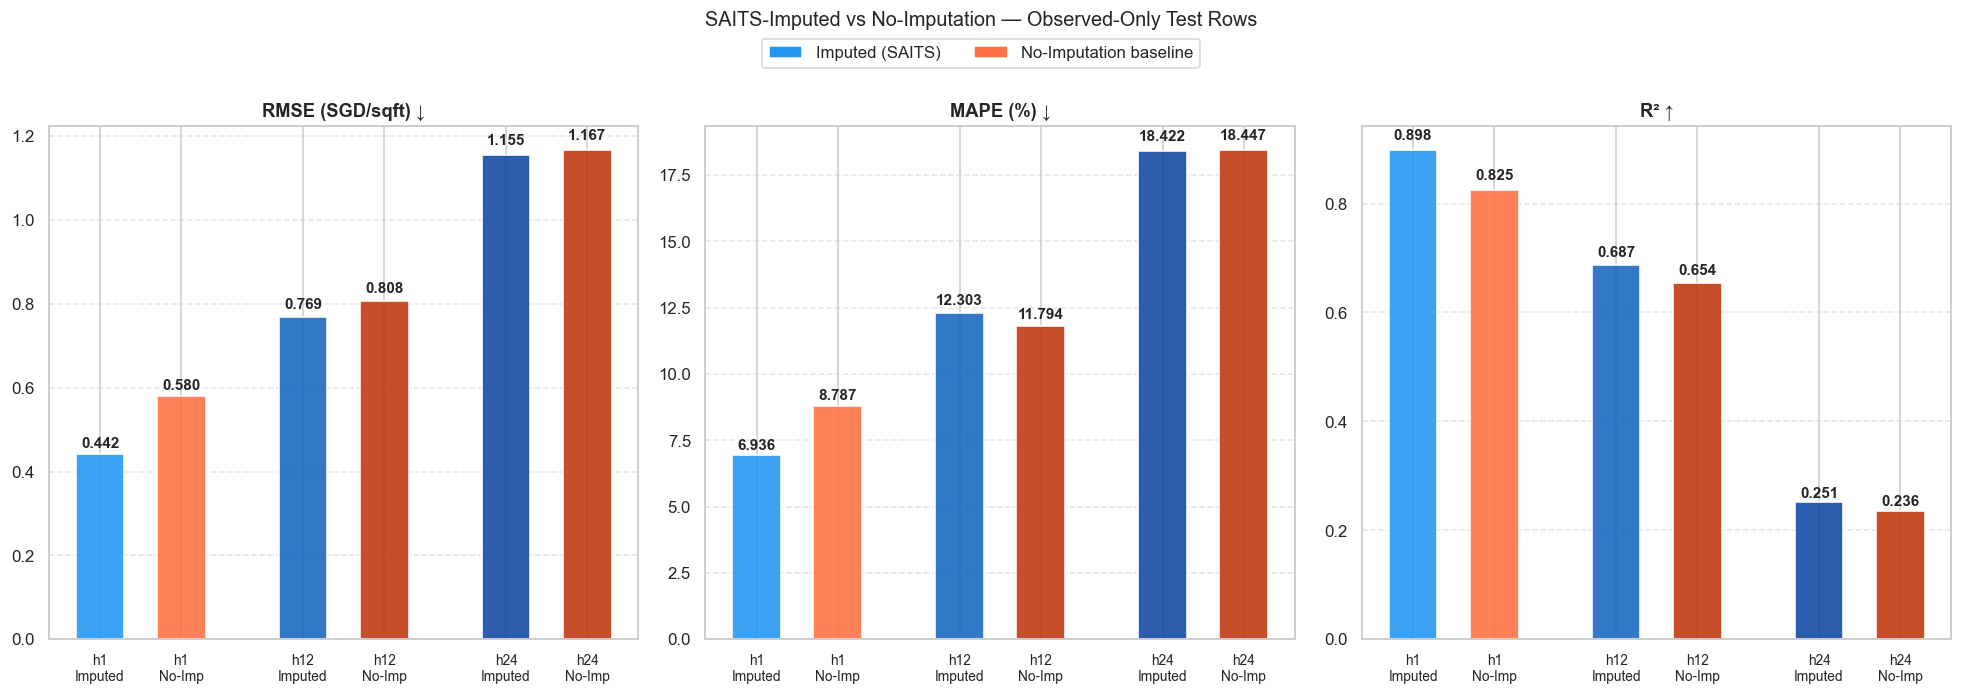

In [25]:
# ── So sánh Imputed vs No-Imputation (Observed-Only Test) ────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics    = ['RMSE', 'MAPE(%)', 'R2']
titles     = ['RMSE (SGD/sqft) ↓', 'MAPE (%) ↓', 'R² ↑']
colors_imp = ['#2196F3', '#1565C0', '#0D47A1']
colors_obs = ['#FF7043', '#BF360C']
x_positions = [0, 1, 2.5, 3.5, 5.0, 6.0]
x_labels    = ['h1\nImputed', 'h1\nNo-Imp', 'h12\nImputed', 'h12\nNo-Imp', 'h24\nImputed', 'h24\nNo-Imp']

for ax, metric, title in zip(axes, metrics, titles):
    vals = [
        res_a_imp_obs[metric],   # h1 Imputed
        res_a_obs_obs[metric],   # h1 No-Imp
        res_b_imp_tobs[metric],  # h12 Imputed
        res_b_obs_tobs[metric],  # h12 No-Imp
        res_c_imp_tobs[metric],  # h24 Imputed
        res_c_obs_tobs[metric],  # h24 No-Imp
    ]
    colors = [colors_imp[0], colors_obs[0], colors_imp[1], colors_obs[1], colors_imp[2], colors_obs[1]]
    bars = ax.bar(x_positions, vals, 0.6, color=colors, alpha=0.88, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.015,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

legend_elements = [
    Patch(facecolor=colors_imp[0], label='Imputed (SAITS)'),
    Patch(facecolor=colors_obs[0], label='No-Imputation baseline'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 1.02), frameon=True)
fig.suptitle('SAITS-Imputed vs No-Imputation — Observed-Only Test Rows', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## 10. Predicted vs Actual

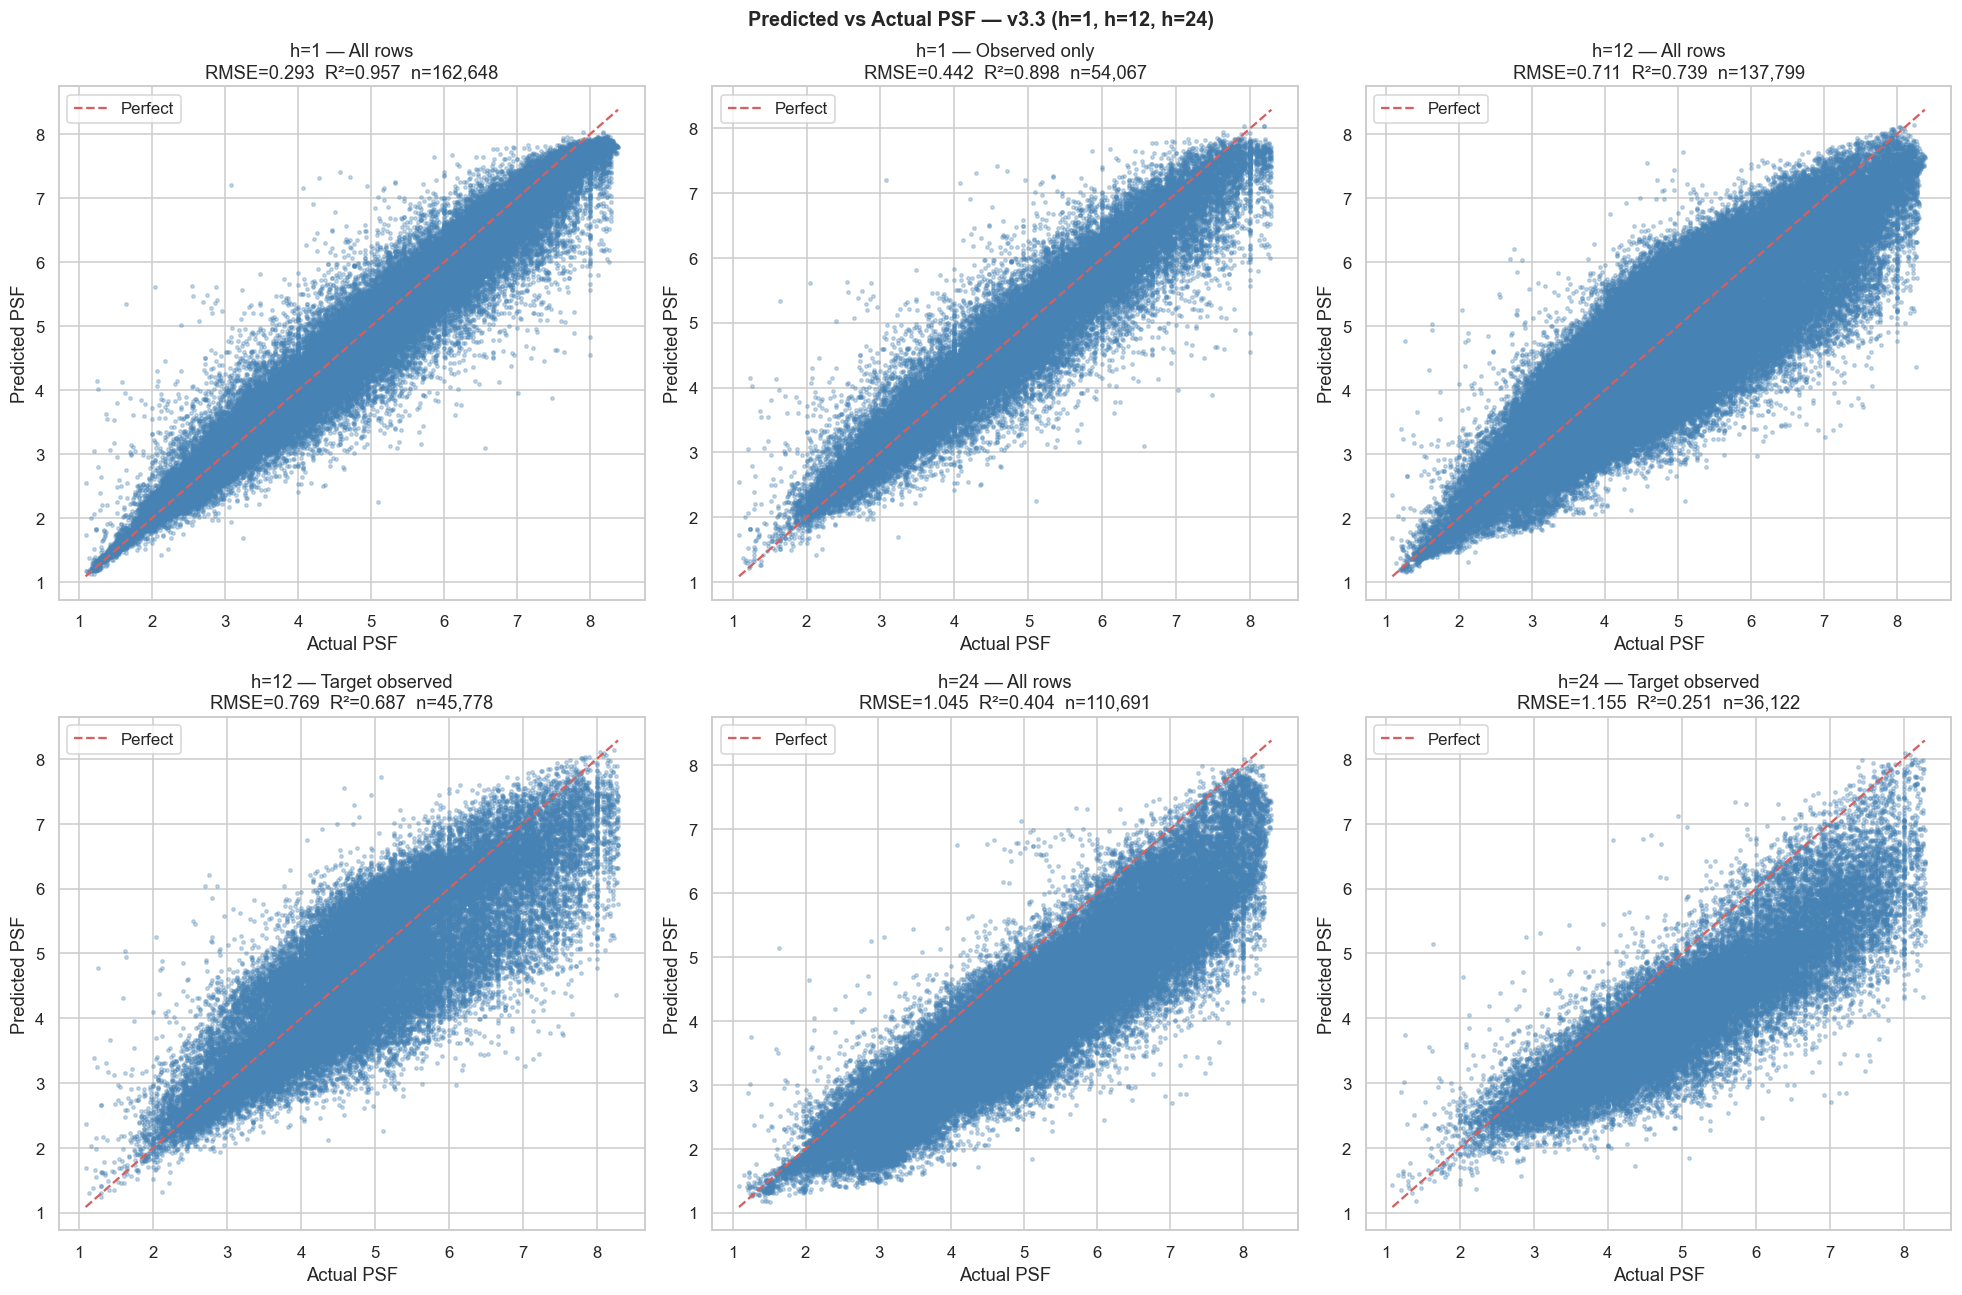

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
configs = [
    (y_test.values,                          y_pred_t1,                         'h=1 — All rows',          axes[0,0]),
    (y_test.values[obs_mask_test],            y_pred_t1[obs_mask_test],           'h=1 — Observed only',     axes[0,1]),
    (y_test_t12.values,                      y_pred_t12,                         'h=12 — All rows',         axes[0,2]),
    (y_test_t12.values[obs_mask_test_t12],   y_pred_t12[obs_mask_test_t12],      'h=12 — Target observed',  axes[1,0]),
    (y_test_t24.values,                      y_pred_t24,                         'h=24 — All rows',         axes[1,1]),
    (y_test_t24.values[obs_mask_test_t24],   y_pred_t24[obs_mask_test_t24],      'h=24 — Target observed',  axes[1,2]),
]
for y_true, y_pred, title, ax in configs:
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0: ax.set_title(f'{title} — no data'); continue
    ax.scatter(y_true[mask], y_pred[mask], alpha=0.3, s=5, color='steelblue')
    lims = [min(y_true[mask].min(), y_pred[mask].min()),
            max(y_true[mask].max(), y_pred[mask].max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    rmse = float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])))
    r2   = float(r2_score(y_true[mask], y_pred[mask]))
    ax.set(xlabel='Actual PSF', ylabel='Predicted PSF',
           title=f'{title}\nRMSE={rmse:.3f}  R²={r2:.3f}  n={mask.sum():,}')
    ax.legend()
fig.suptitle('Predicted vs Actual PSF — v3.3 (h=1, h=12, h=24)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Feature Importance

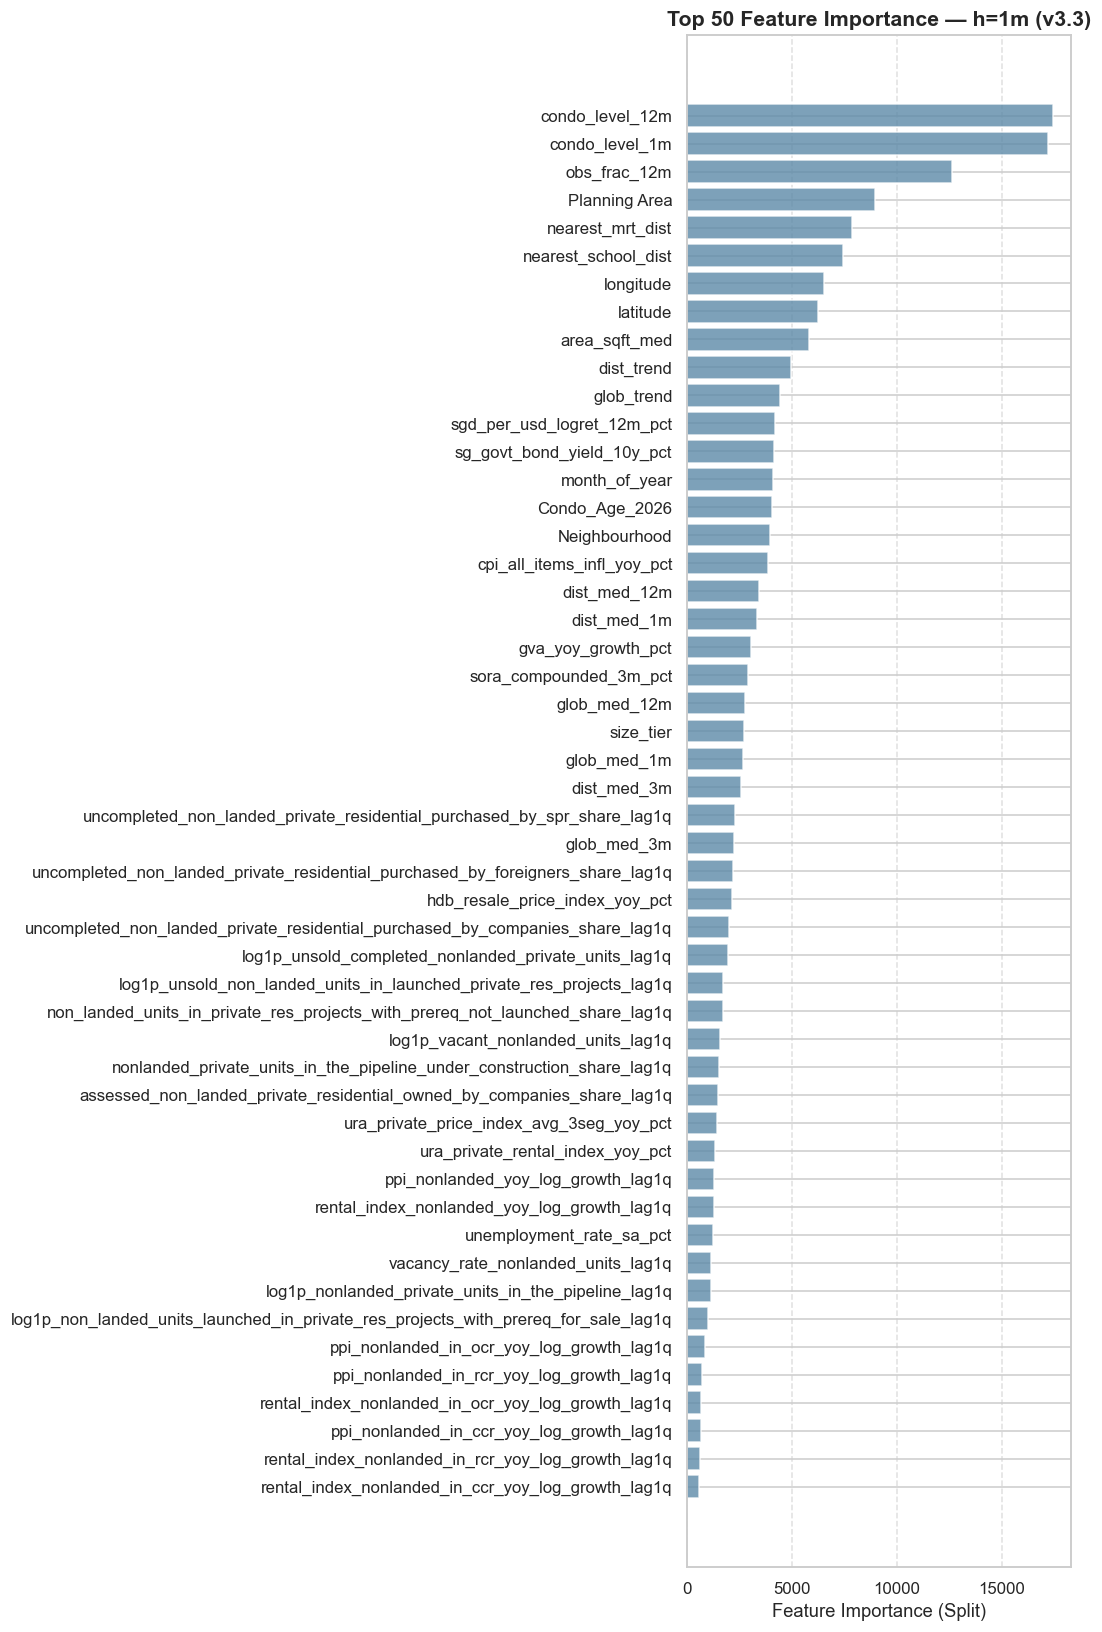

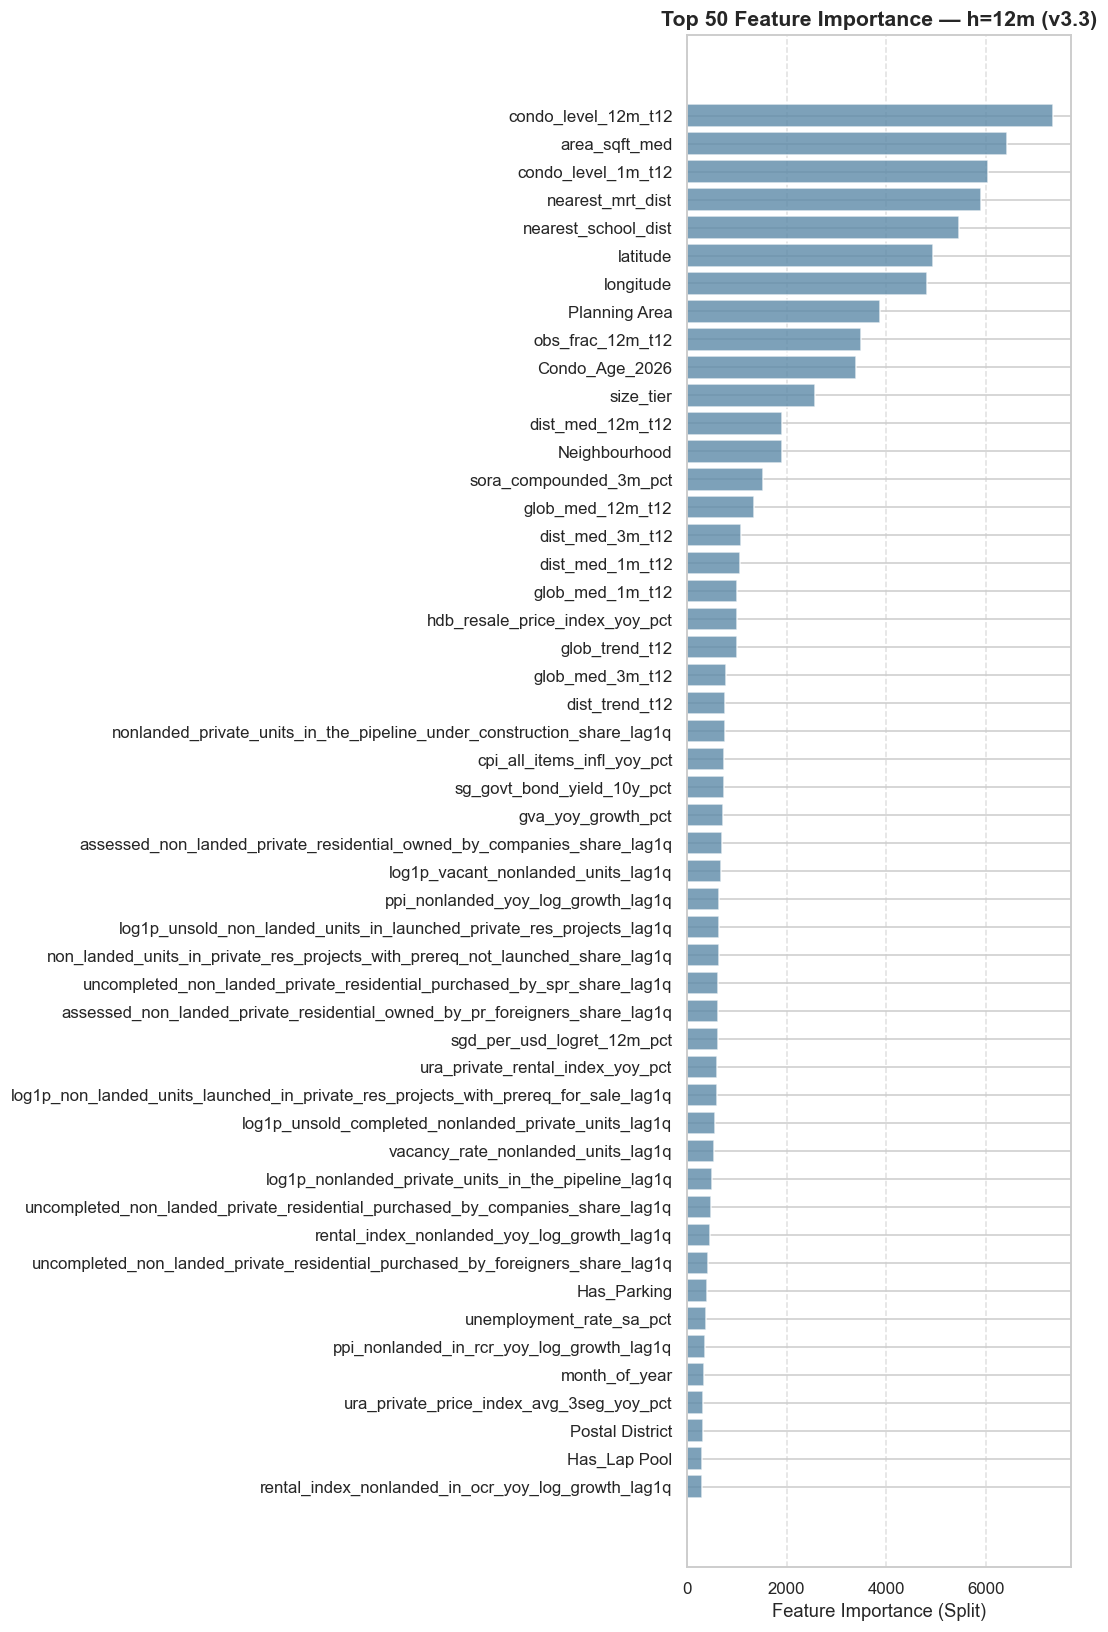

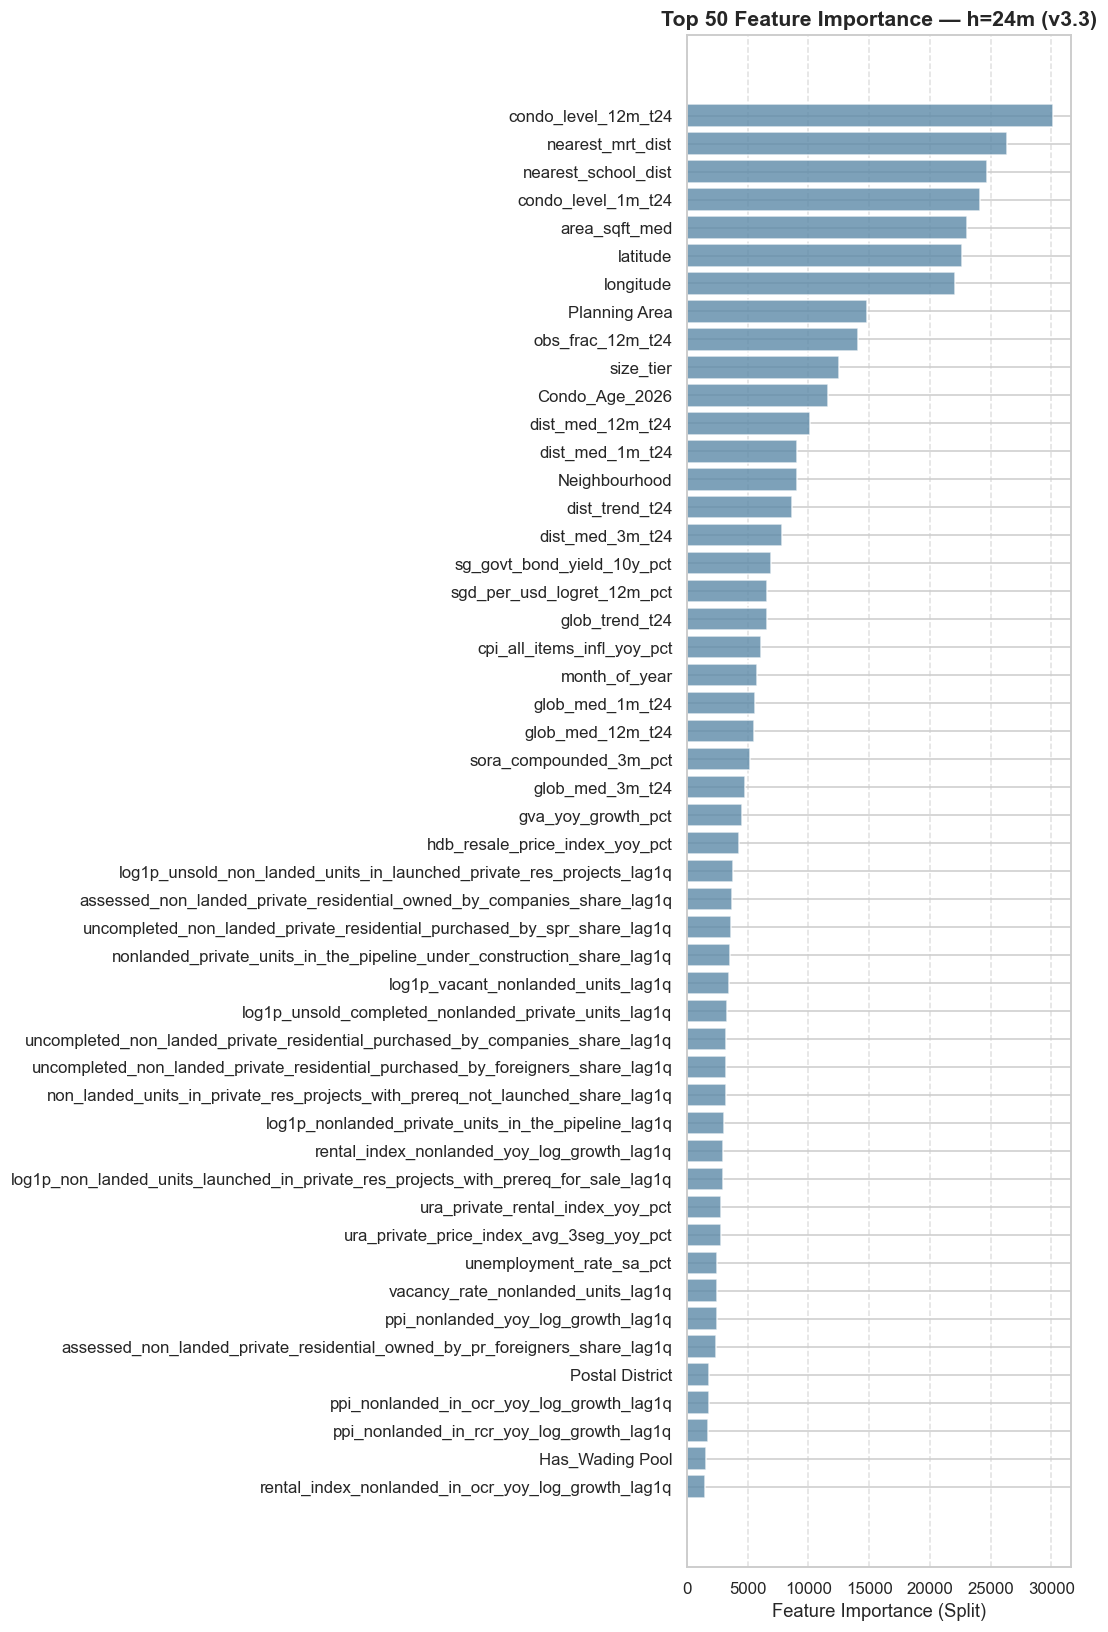

In [27]:
importance_type = 'split'

for model, feat_cols, horizon in [
    (lgb_full,     FEATURES_A,   1),
    (lgb_full_t12, FEATURES_T12, 12),
    (lgb_full_t24, FEATURES_T24, 24),
]:
    importance_values = model.booster_.feature_importance(importance_type=importance_type)
    df_imp = pd.DataFrame({'Feature': feat_cols, 'Importance': importance_values})
    df_imp = df_imp.sort_values(by='Importance', ascending=False).head(50)
    plt.figure(figsize=(10, 15))
    plt.barh(df_imp['Feature'], df_imp['Importance'], color='#5D8AA8', alpha=0.8)
    plt.xlabel(f'Feature Importance ({importance_type.capitalize()})')
    plt.title(f'Top 50 Feature Importance — h={horizon}m (v3.3)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

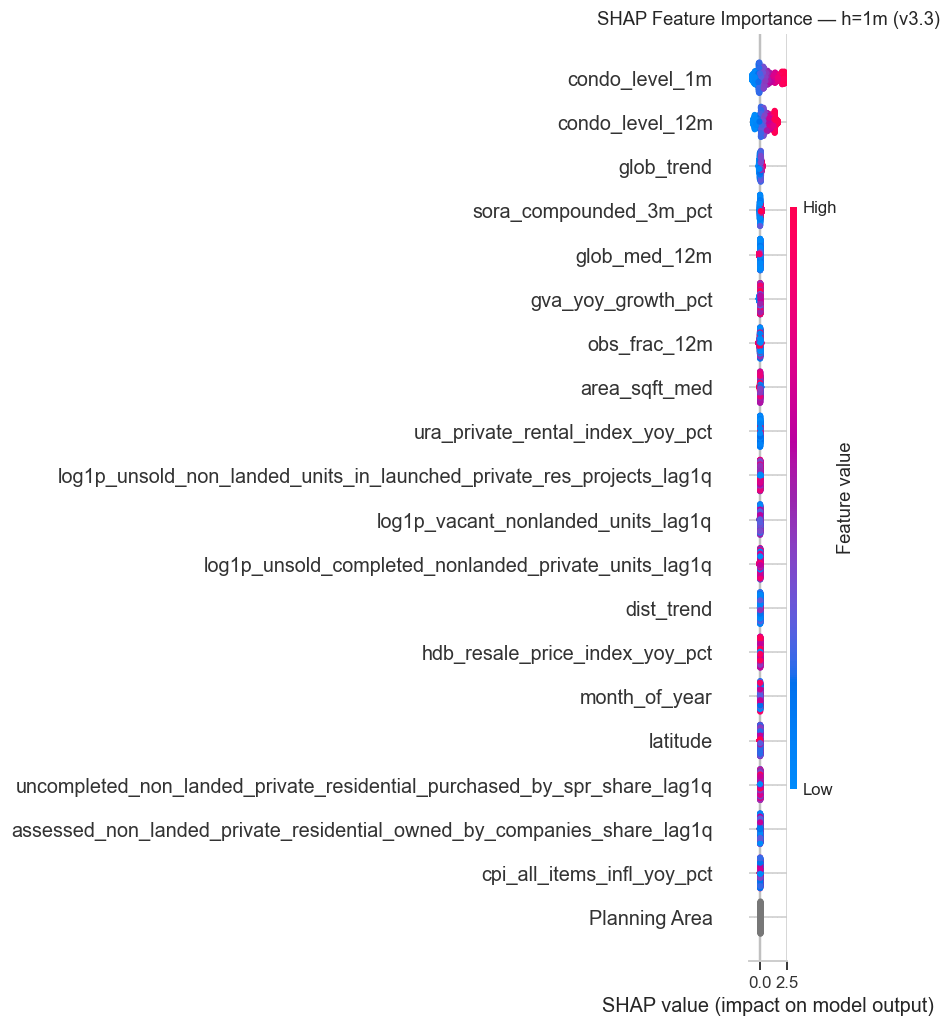

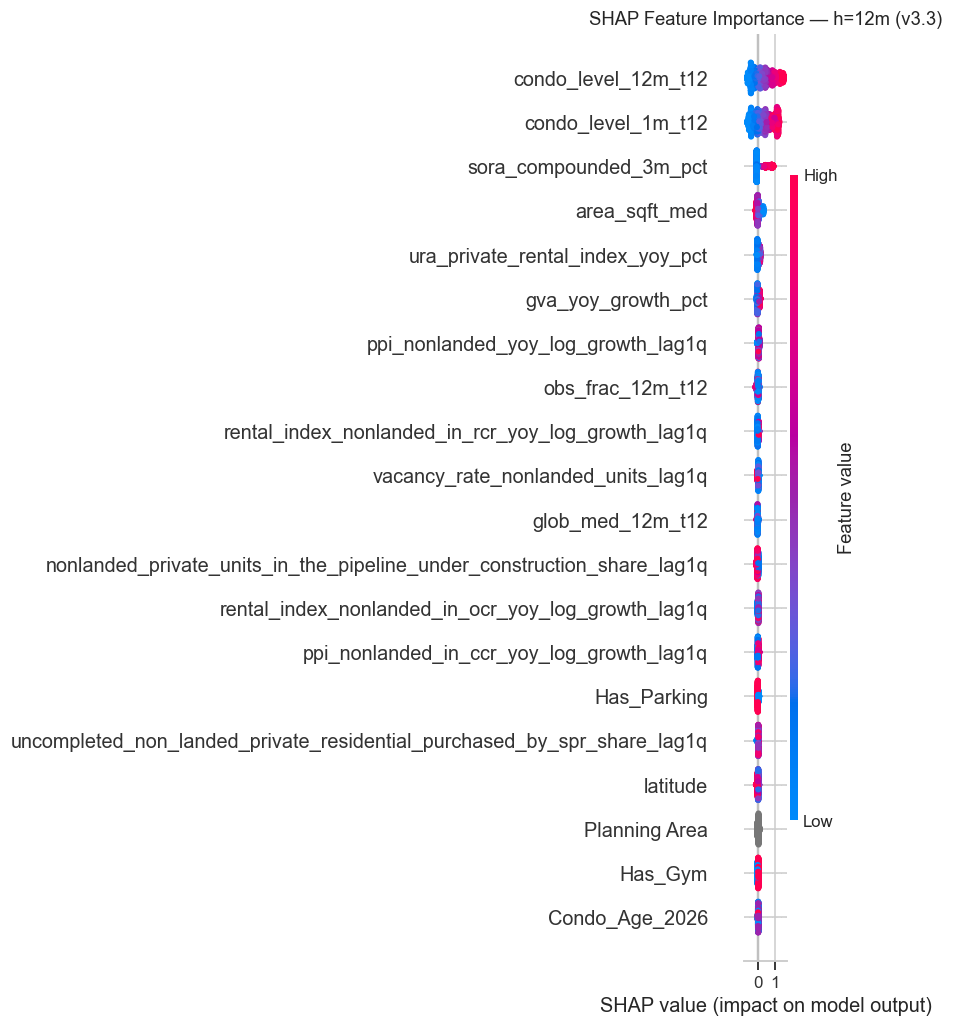

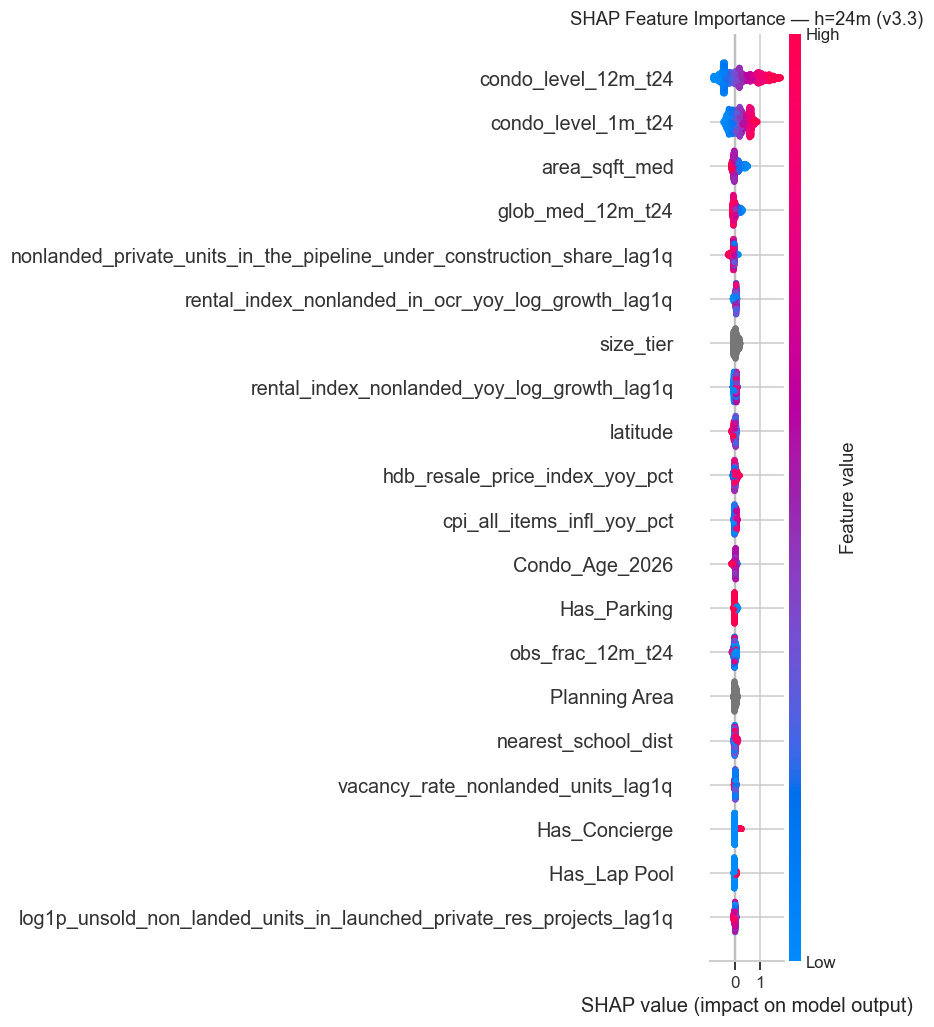

In [28]:
if SHAP_AVAILABLE:
    for model, X_src, feat_cols, horizon in [
        (lgb_full,     X_test,     FEATURES_A,   1),
        (lgb_full_t12, X_test_t12, FEATURES_T12, 12),
        (lgb_full_t24, X_test_t24, FEATURES_T24, 24),
    ]:
        samp = X_src.iloc[:2000]
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(samp)
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, samp, feature_names=feat_cols,
                          max_display=20, show=False, plot_type='dot')
        plt.title(f'SHAP Feature Importance — h={horizon}m (v3.3)', fontsize=12)
        plt.tight_layout(); plt.show()
else:
    print('SHAP not available — pip install shap')

## 12. Export Predictions

In [29]:
parts = []
for df_src, mask_src, y_pred_imp, y_pred_obs_m, y_true_ser, horizon, obs_mask in [
    (df,     mask_test,     y_pred_t1,  y_pred_obs_t1,  y_test,     1,  obs_mask_test),
    (df_t12, mask_test_t12, y_pred_t12, y_pred_obs_t12, y_test_t12, 12, obs_mask_test_t12),
    (df_t24, mask_test_t24, y_pred_t24, y_pred_obs_t24, y_test_t24, 24, obs_mask_test_t24),
]:
    tmp = df_src.loc[mask_src, ['project_idx', 'condo_name', 'size_tier',
                                 'district', 'segment', 'date', 'period',
                                 'rent_psf_imp', 'was_observed']].copy()
    tmp['horizon']           = horizon
    tmp['y_true']            = y_true_ser.values
    tmp['y_pred_imputed']    = y_pred_imp
    tmp['y_pred_obs_only']   = y_pred_obs_m
    tmp['residual_imputed']  = y_true_ser.values - y_pred_imp
    tmp['residual_obs_only'] = y_true_ser.values - y_pred_obs_m
    tmp['target_observed']   = obs_mask
    parts.append(tmp)

df_export = pd.concat(parts, ignore_index=True)
df_export['y_true'] = df_export['y_true'].where(df_export['target_observed'] == True)

OUT_CSV = './URA_rental_predictions_lgbm_saits_v3.2_supply_macro_optuna_h24obs.csv'
df_export.to_csv(OUT_CSV, index=False)
print(f'Saved {OUT_CSV}  ({len(df_export):,} rows x {len(df_export.columns)} cols)')

Saved ./URA_rental_predictions_lgbm_saits_v3.2_supply_macro_optuna_h24obs.csv  (411,138 rows x 16 cols)
